# Synthèse — contagion SIS ↔ E_i (notebook propre)

Reprise propre de l'analyse, appuyée sur le package `code/` (détection, fits SIS, balayage B/R, tout en cache `cache/`). Plan :

1. **Clustering par période** — seuil scale-free (ρc choisi pour une distribution des degrés en loi de puissance), clustering moyen par période de crise.
2. **Signaux réseau** — λ_max/⟨λ⟩ (normalisé), ⟨|C_ij|⟩, ⟨r⟩, avec les montées de crise (détection `monthly_correlations` : pics de ⟨|C|⟩).
3. **Balayage (B, R)** — méthode des pics ; augmenter B et R sélectionne-t-il les mêmes actifs qu'à B=R=1 ?
4. **Test null** — fit SIS sur une montée individuelle de l'actif **hors** crise collective : le SIS ne marche-t-il que sur les crises collectives ?
5. **Tableau** — nb d'actifs retenus par méthode × période + % d'actifs communs à toutes les méthodes.
6. **Communautés** — par période de crise : graphe + Louvain, les actifs en crise sont-ils dans une même communauté ?

In [1]:
import sys, warnings
sys.path.insert(0, 'code')
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from scipy.stats import linregress
from data import build_context
import pipeline, periods, selection, sis, config

# Contexte partagé (données + matrices A + caches base/crisis_map/...)
ctx = build_context()
P  = pipeline.load_periods(ctx)                 # intervals_chrono, crisis_map
PK = pipeline.fit_peaks(ctx, P['crisis_map'])   # peak_rises (montées), peak_pd (fits SIS)
SP = pipeline.spectral(ctx)                     # diag : λ_max/⟨λ⟩, ⟨|C|⟩, ⟨r⟩

peak_rises = PK['peak_rises']                   # 17 montées creux→sommet
peak_pd    = PK['peak_pd']                      # (cache, fits) par montée
crisis_map = P['crisis_map']
diag       = SP['diag']
# x recentré pour les courbes spectrales : la fenêtre trailing (WINDOW_SPEC) est
# horodatée en fin -> on la recentre (milieu) pour l'aligner sur les bandes de crise.
_endpos    = np.arange(len(diag)) * config.STEP_SPEC + config.WINDOW_SPEC - 1
diag_x     = ctx.data.index[_endpos - (config.WINDOW_SPEC - 1) // 2]
all_days   = pd.to_datetime(ctx.all_days)
arr        = ctx.data.values
N          = ctx.N
print(f'{N} actifs, {len(all_days)} jours, {len(peak_rises)} montées de crise')

N = 146 actifs, T = 13360 obs ; 2019-04-01 10:00:00 -> 2023-05-03 15:30:00
[cache] OK  base
1031 jours ; <|C_ij|> moyen = 0.4686
[cache] OK  crisis_map
[cache] OK  peak_period_data
[cache] OK  spectral_diag
146 actifs, 1031 jours, 17 montées de crise


## 1. Clustering par période 

Pour chaque fenêtre on choisit le seuil **ρc** minimal rendant la distribution des degrés **convexe** (proxy loi de puissance / scale-free), puis on mesure le **clustering moyen pondéré** du graphe seuillé. On calcule :
- la **courbe** de clustering dans le temps (fenêtres 1 jour) ;
- par **période de crise** (montées de pics) : ρc, le clustering sur la matrice de la période, et le **minimum** du clustering dans la fenêtre.

In [2]:
def scale_free_threshold(C, start=0.5, step=0.01, cap=0.95):
    """Seuil ρc minimal (balayage fin depuis 0.10 ; <0.10 = graphe quasi-complet, faux positif) rendant la distribution des degrés convexe."""
    rc = start
    while rc <= cap:
        A = (np.abs(C) >= rc).astype(int); np.fill_diagonal(A, 0); deg = A.sum(1)
        counts = np.bincount(deg, minlength=int(deg.max()) + 1).astype(float)
        kmax = int(np.quantile(deg, 0.9))
        if (kmax < 2) or np.all(np.diff(counts[:kmax + 1], 2) >= 0):
            return rc
        rc = round(rc + step, 2)
    return cap

def clustering_at_sft(C):
    """(ρc, clustering moyen pondéré) du graphe seuillé au seuil scale-free."""
    rc = scale_free_threshold(C)
    Wt = np.abs(C) * (np.abs(C) >= rc); np.fill_diagonal(Wt, 0.0)
    return rc, nx.average_clustering(nx.from_numpy_array(Wt), weight='weight')

# Courbe de clustering : fenêtres 1 jour ouvré (13 obs)
SHORT = 13
idx = ctx.data.index
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    clus, cdates = [], []
    for i in range(len(arr) // SHORT):
        sub = arr[i * SHORT:(i + 1) * SHORT]
        _, cl = clustering_at_sft(np.nan_to_num(np.corrcoef(sub.T)))
        clus.append(cl); cdates.append(idx[(i + 1) * SHORT - 1])
clus = np.array(clus); cdates = pd.to_datetime(cdates)
# Lissage 5 jours pour l'AFFICHAGE uniquement (clus reste brut pour le tableau/l'histogramme)
clus_disp = pd.Series(clus).rolling(5, center=True, min_periods=1).mean().values
print(f'courbe clustering : {len(clus)} fenêtres de 1 jour (lissage 5 j à l\'affichage)')

courbe clustering : 1027 fenêtres de 1 jour (lissage 5 j à l'affichage)


,debut,fin,n_crise,rho_c,clust_periode,clust_min_fenetre
0,2019-04-01,2019-05-15,73,0.69,0.1543,0.0487
1,2019-07-22,2019-08-14,38,0.79,0.1108,0.0585
2,2019-11-19,2020-02-04,19,0.62,0.1017,0.0335
3,2020-02-11,2020-03-06,139,0.89,0.1109,0.0613
4,2020-05-29,2020-06-16,94,0.88,0.1055,0.0538
5,2020-08-24,2020-09-14,5,0.76,0.1536,0.0177
6,2020-10-19,2020-11-04,25,0.80,0.1321,0.0349
7,2020-12-10,2021-03-04,6,0.61,0.1240,0.0392
8,2021-03-29,2021-05-13,8,0.69,0.1256,0.0366
9,2021-08-05,2021-09-29,37,0.74,0.0963,0.0495


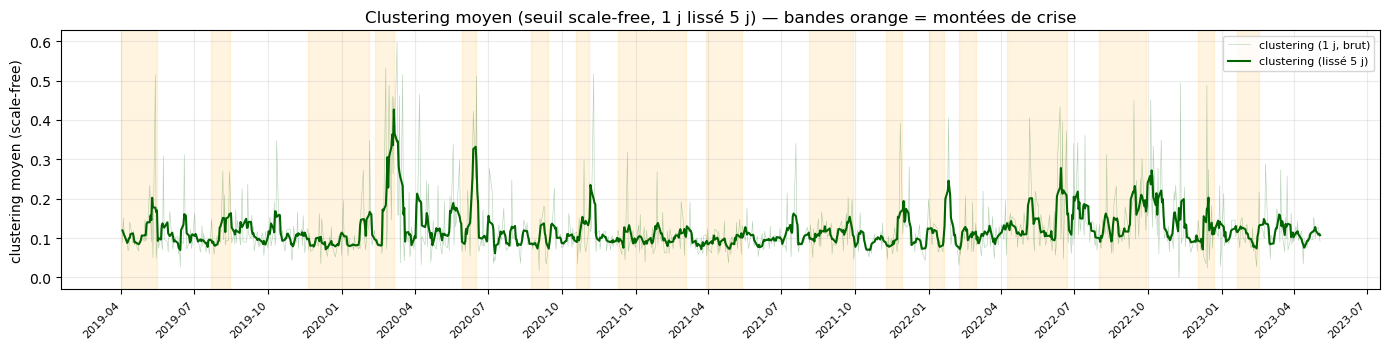

In [3]:
# Tableau par période de crise (montée)
rows = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for (pa, pb) in peak_rises:
        d0, d1 = all_days[pa], all_days[pb]
        obs = (idx >= d0) & (idx <= d1)
        rc, clp = clustering_at_sft(np.nan_to_num(np.corrcoef(arr[np.asarray(obs)].T)))
        inwin = (cdates >= d0) & (cdates <= d1)
        cmin = clus[inwin].min() if inwin.any() else np.nan
        rows.append({'debut': str(d0)[:10], 'fin': str(d1)[:10],
                     'n_crise': len(peak_pd[(pa, pb)][0]), 'rho_c': rc,
                     'clust_periode': round(clp, 4), 'clust_min_fenetre': round(cmin, 4)})
clust_table = pd.DataFrame(rows)
display(clust_table)

# Courbe de clustering avec bandes de crise (lissée 5 j à l'affichage)
fig, ax = plt.subplots(figsize=(14, 3.6))
ax.plot(cdates, clus, color='darkgreen', lw=0.4, alpha=0.3, label='clustering (1 j, brut)')
ax.plot(cdates, clus_disp, color='darkgreen', lw=1.5, label='clustering (lissé 5 j)')
for (pa, pb) in peak_rises:
    ax.axvspan(all_days[pa], all_days[pb], color='orange', alpha=0.12)
ax.set_ylabel('clustering moyen (scale-free)'); ax.grid(alpha=0.25); ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_title('Clustering moyen (seuil scale-free, 1 j lissé 5 j) — bandes orange = montées de crise')
plt.tight_layout(); plt.show()

### Distributions associées

Pour juger le seuil scale-free et le clustering : distribution des **degrés** (crise COVID vs fenêtre calme) en linéaire et log-log, histogramme du **clustering** sur toutes les fenêtres, et distribution des **corrélations** C_ij (la vraie signature de crise).

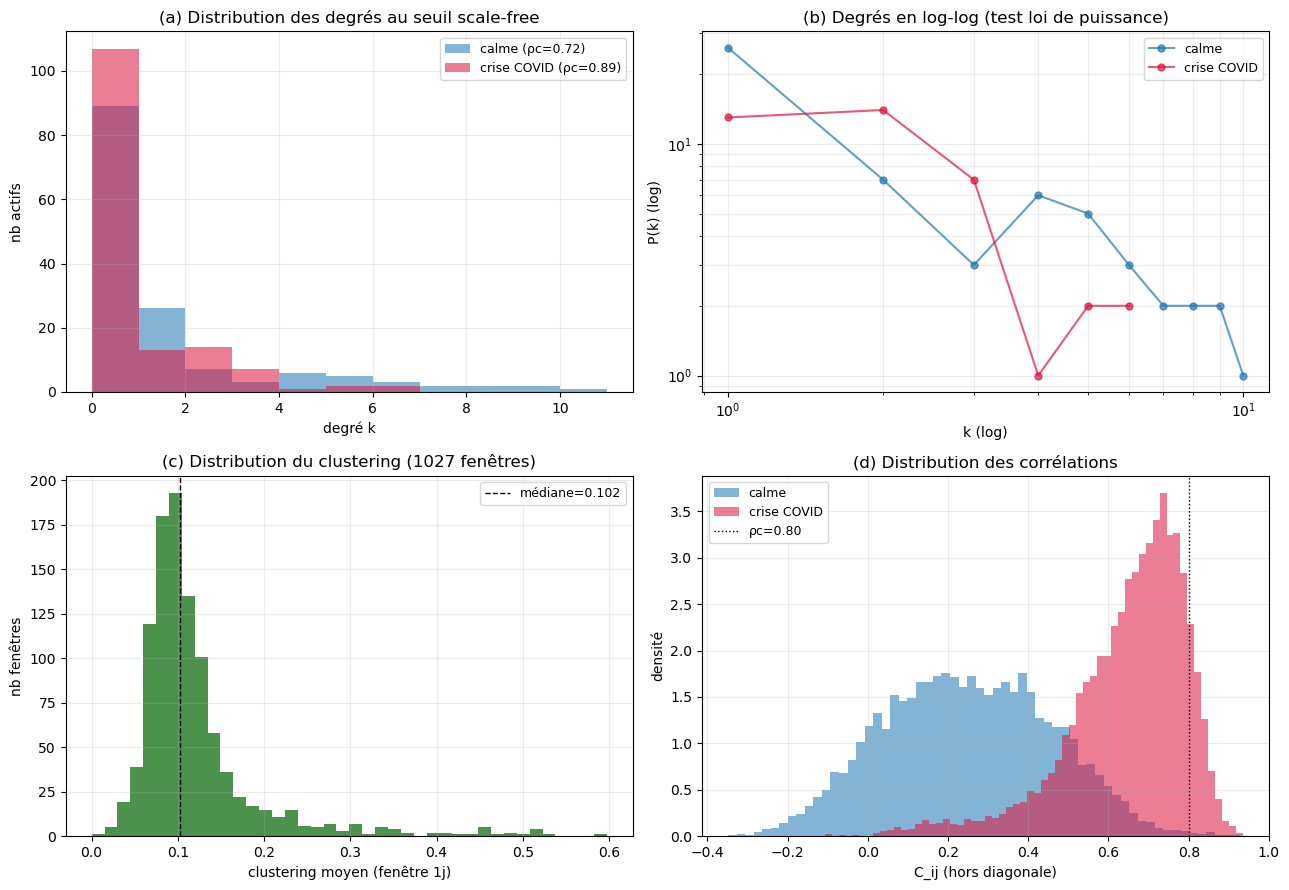

In [4]:
# Distributions associees : degres (crise vs calme), clustering, correlations
def _corr_window(d0, d1):
    obs = (idx >= d0) & (idx <= d1)
    return np.nan_to_num(np.corrcoef(arr[np.asarray(obs)].T))

def _degrees(C, rc):
    A = (np.abs(C) >= rc).astype(int); np.fill_diagonal(A, 0); return A.sum(1)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    C_crise = _corr_window(all_days[peak_rises[3][0]], all_days[peak_rises[3][1]])  # COVID
    C_calme = _corr_window(pd.Timestamp('2021-06-15'), pd.Timestamp('2021-07-25'))  # hors bande
rc_cr, rc_ca = scale_free_threshold(C_crise), scale_free_threshold(C_calme)
d_cr, d_ca = _degrees(C_crise, rc_cr), _degrees(C_calme, rc_ca)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
ax = axes[0, 0]
bins = np.arange(0, max(d_cr.max(), d_ca.max()) + 2)
ax.hist(d_ca, bins=bins, alpha=0.55, color='tab:blue', label=f'calme (ρc={rc_ca})')
ax.hist(d_cr, bins=bins, alpha=0.55, color='crimson', label=f'crise COVID (ρc={rc_cr})')
ax.set_xlabel('degré k'); ax.set_ylabel('nb actifs'); ax.legend(fontsize=9); ax.grid(alpha=0.25)
ax.set_title('(a) Distribution des degrés au seuil scale-free')

ax = axes[0, 1]
for d, c, lab in [(d_ca, 'tab:blue', 'calme'), (d_cr, 'crimson', 'crise COVID')]:
    cnt = np.bincount(d); k = np.nonzero(cnt)[0]; k = k[k > 0]
    ax.loglog(k, cnt[k], 'o-', color=c, alpha=0.7, ms=5, label=lab)
ax.set_xlabel('k (log)'); ax.set_ylabel('P(k) (log)'); ax.legend(fontsize=9); ax.grid(alpha=0.25, which='both')
ax.set_title('(b) Degrés en log-log (test loi de puissance)')

ax = axes[1, 0]
ax.hist(clus, bins=40, color='darkgreen', alpha=0.7)
ax.axvline(np.median(clus), color='k', ls='--', lw=1, label=f'médiane={np.median(clus):.3f}')
ax.set_xlabel('clustering moyen (fenêtre 1j)'); ax.set_ylabel('nb fenêtres')
ax.legend(fontsize=9); ax.grid(alpha=0.25)
ax.set_title(f'(c) Distribution du clustering ({len(clus)} fenêtres)')

ax = axes[1, 1]
iu = np.triu_indices_from(C_crise, k=1)
ax.hist(C_calme[iu], bins=60, density=True, alpha=0.55, color='tab:blue', label='calme')
ax.hist(C_crise[iu], bins=60, density=True, alpha=0.55, color='crimson', label='crise COVID')
ax.axvline(0.8, color='k', ls=':', lw=1, label='ρc=0.80')
ax.set_xlabel('C_ij (hors diagonale)'); ax.set_ylabel('densité'); ax.legend(fontsize=9); ax.grid(alpha=0.25)
ax.set_title('(d) Distribution des corrélations')
plt.tight_layout(); plt.show()

#### Degré vs rang

Degrés triés par ordre décroissant tracés contre leur rang (rank plot, façon Zipf). En log-log, une **droite** = loi de puissance ; une décroissance brutale puis un plateau = peu de hubs et une masse d'actifs faiblement connectés.

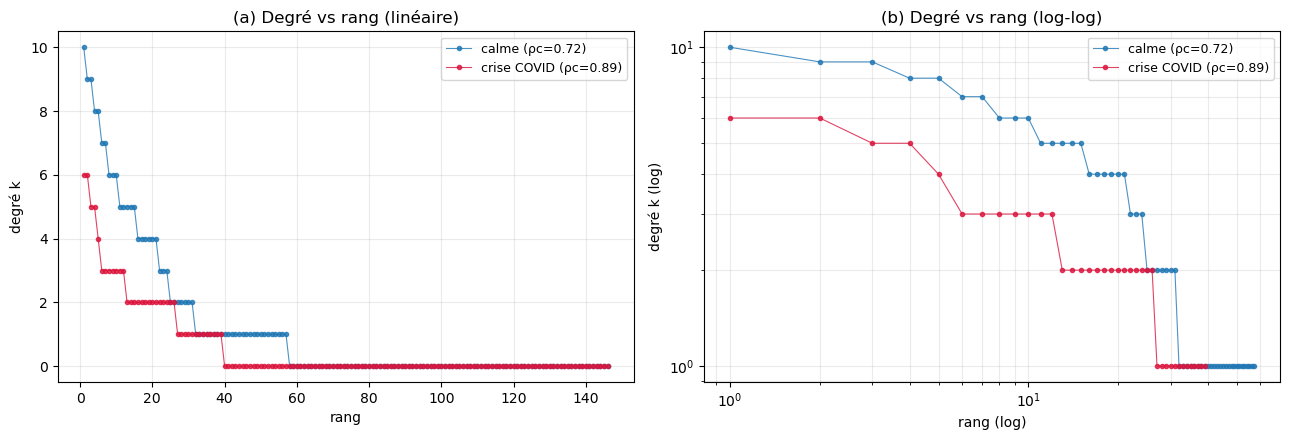

In [5]:
# Degré vs rang (rank plot, log-log) : test loi de puissance
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))
for d, c, lab, rc in [(d_ca, 'tab:blue', 'calme', rc_ca), (d_cr, 'crimson', 'crise COVID', rc_cr)]:
    ds = np.sort(d)[::-1]
    rank = np.arange(1, len(ds) + 1)
    axL.plot(rank, ds, 'o-', color=c, ms=3, lw=0.8, alpha=0.8, label=f'{lab} (ρc={rc})')
    m = ds > 0
    axR.loglog(rank[m], ds[m], 'o-', color=c, ms=3, lw=0.8, alpha=0.8, label=f'{lab} (ρc={rc})')
axL.set_xlabel('rang'); axL.set_ylabel('degré k'); axL.set_title('(a) Degré vs rang (linéaire)')
axL.grid(alpha=0.25); axL.legend(fontsize=9)
axR.set_xlabel('rang (log)'); axR.set_ylabel('degré k (log)'); axR.set_title('(b) Degré vs rang (log-log)')
axR.grid(alpha=0.25, which='both'); axR.legend(fontsize=9)
plt.tight_layout(); plt.show()

#### Degré vs rang par période

Un rank plot log-log par montée de crise (17 panneaux). Permet de voir si la « scale-free-ité » du réseau seuillé varie d'une crise à l'autre.

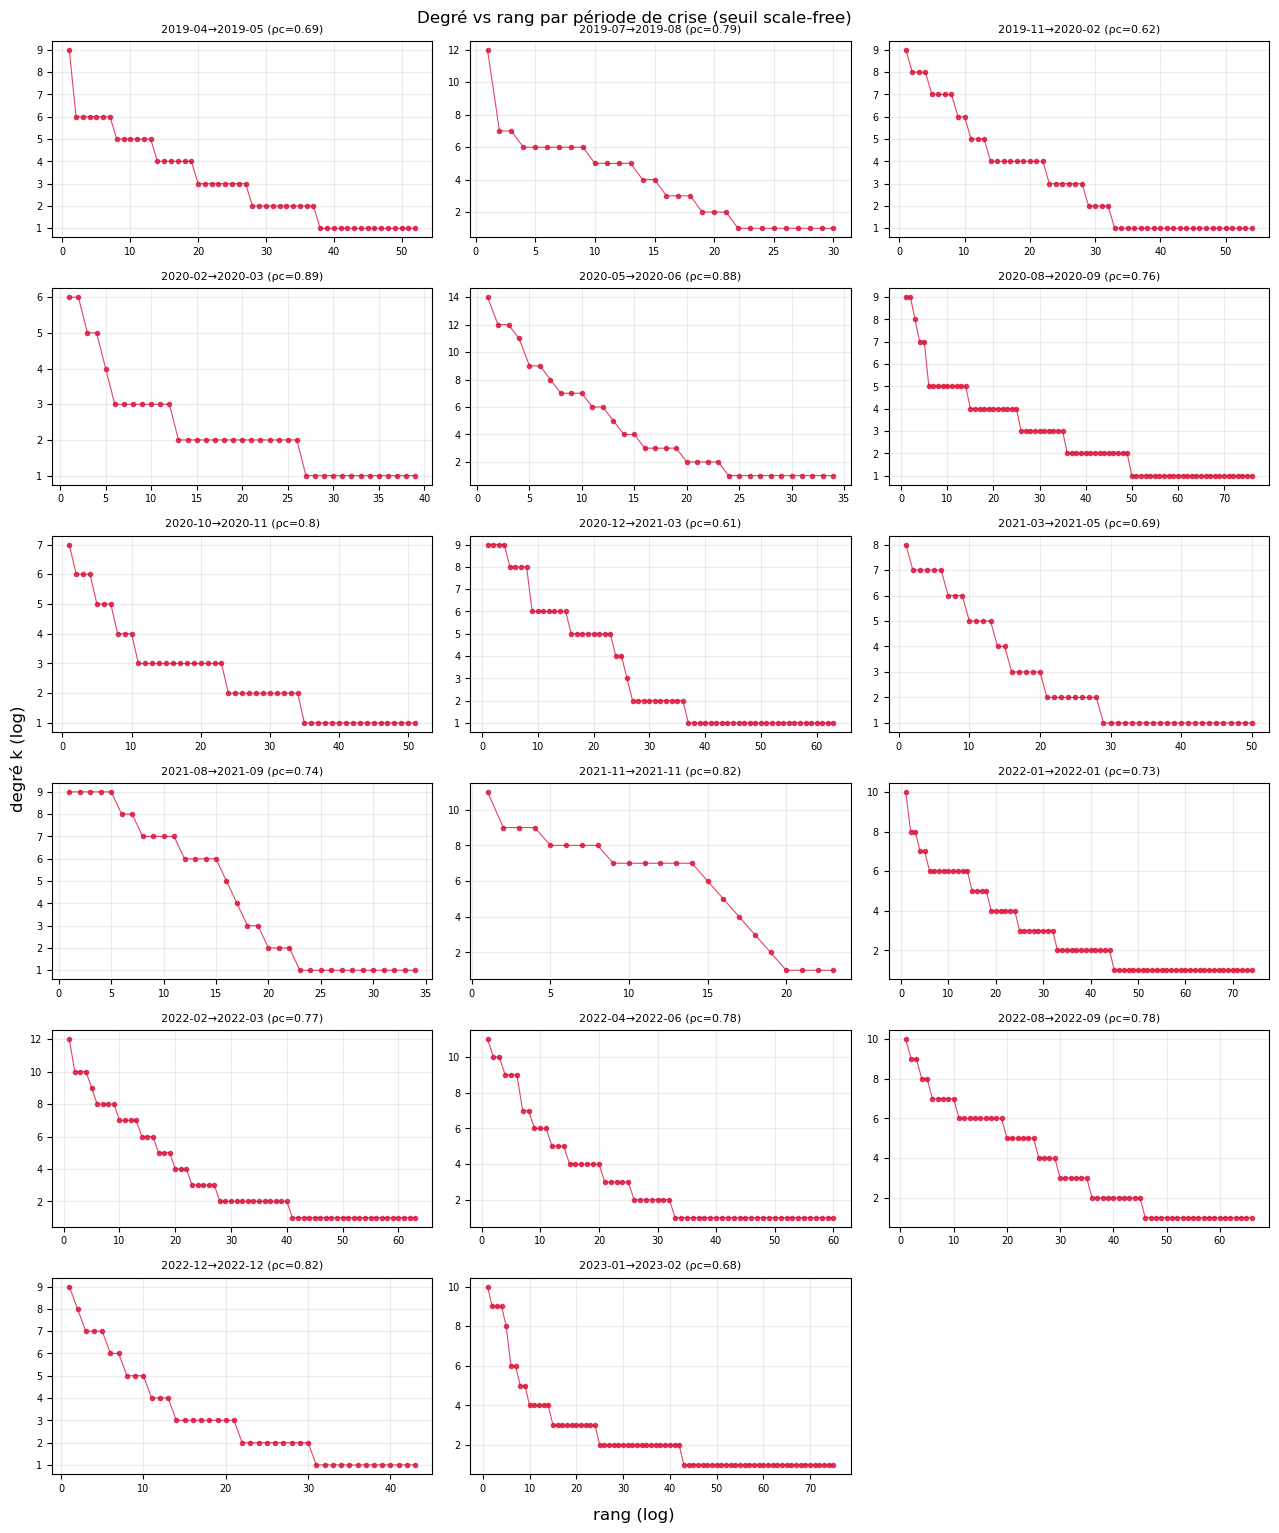

In [6]:
# Degré vs rang (log-log) — un panneau par période de crise (montée)
n = len(peak_rises); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.6 * nrow))
axes = axes.ravel()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for j, (pa, pb) in enumerate(peak_rises):
        d0, d1 = all_days[pa], all_days[pb]
        C = _corr_window(d0, d1); rc = scale_free_threshold(C)
        d = _degrees(C, rc); ds = np.sort(d)[::-1]
        rank = np.arange(1, len(ds) + 1); m = ds > 0
        ax = axes[j]
        ax.plot(rank[m], ds[m], 'o-', color='crimson', ms=3, lw=0.8, alpha=0.8)
        ax.set_title(f'{str(d0)[:7]}→{str(d1)[:7]} (ρc={rc})', fontsize=8)
        ax.grid(alpha=0.25, which='both'); ax.tick_params(labelsize=7)
for k in range(n, len(axes)):
    axes[k].axis('off')
fig.supxlabel('rang (log)'); fig.supylabel('degré k (log)')
fig.suptitle('Degré vs rang par période de crise (seuil scale-free)', fontsize=12)
plt.tight_layout(); plt.show()

#### Convexité de P(k) par période

C'est *cette* distribution (P(k) = nb d'actifs de degré k) que le seuil scale-free rend convexe : on monte ρc tant que la dérivée seconde de P(k) sur **[0, kmax]** (kmax = 90ᵉ percentile des degrés, ligne pointillée) n'est pas ≥ 0. La portion **rouge** = zone effectivement testée. Quand kmax < 2 le test est trivial → ρc reste à 0.80.

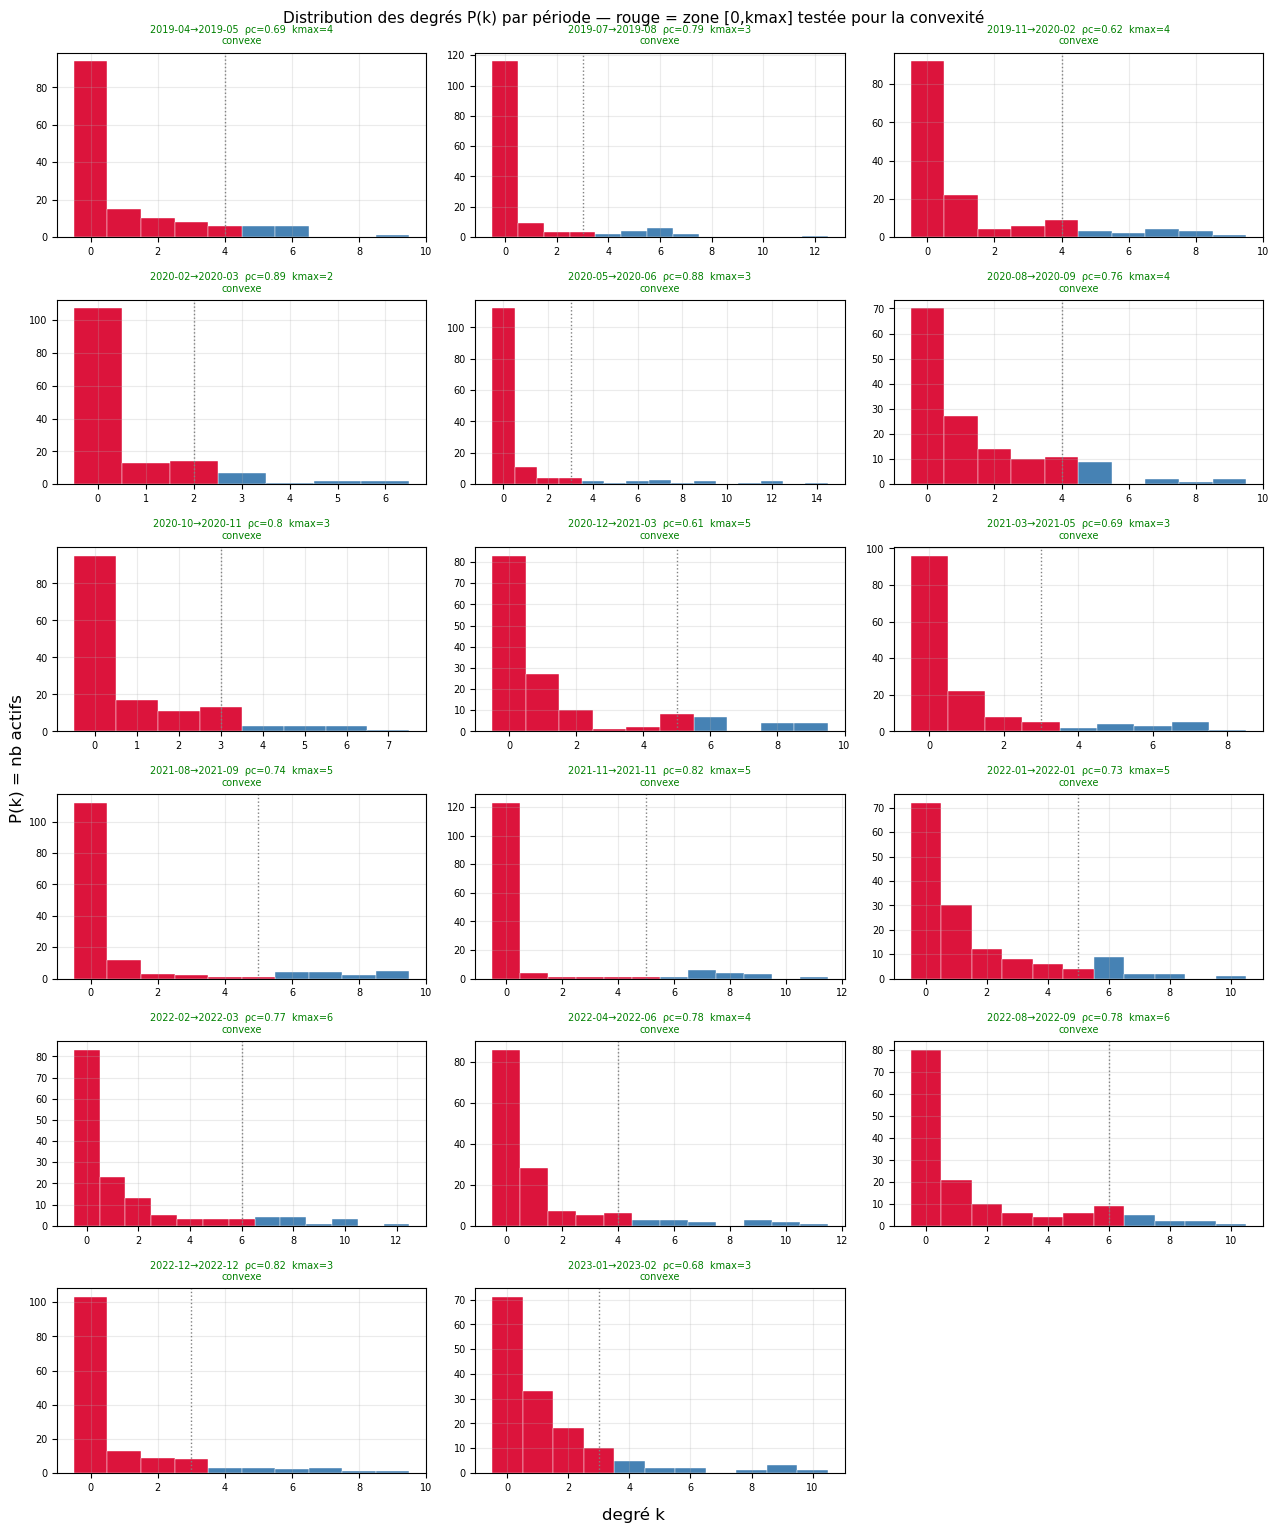

In [7]:
# Distribution des degrés P(k) par période — l'objet rendu convexe par le seuil (Achitouv)
n = len(peak_rises); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.6 * nrow)); axes = axes.ravel()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for j, (pa, pb) in enumerate(peak_rises):
        d0, d1 = all_days[pa], all_days[pb]
        C = _corr_window(d0, d1); rc = scale_free_threshold(C); deg = _degrees(C, rc)
        counts = np.bincount(deg, minlength=int(deg.max()) + 1).astype(float)
        kmax = int(np.quantile(deg, 0.9)); k = np.arange(len(counts))
        # convexite sur la zone testee [0, kmax]
        seg = counts[:kmax + 1]
        convex = (kmax < 2) or np.all(np.diff(seg, 2) >= 0)
        ax = axes[j]
        ax.bar(k, counts, width=1.0, color='steelblue', edgecolor='white', lw=0.3)
        ax.bar(k[:kmax + 1], seg, width=1.0, color='crimson', edgecolor='white', lw=0.3)  # zone testee
        ax.axvline(kmax, color='gray', ls=':', lw=1)
        tag = 'convexe' if convex else 'NON convexe'
        ax.set_title(f'{str(d0)[:7]}→{str(d1)[:7]}  ρc={rc}  kmax={kmax}\n{tag}',
                     fontsize=7, color='green' if convex else 'darkred')
        ax.grid(alpha=0.25); ax.tick_params(labelsize=7)
for kk in range(n, len(axes)):
    axes[kk].axis('off')
fig.supxlabel('degré k'); fig.supylabel('P(k) = nb actifs')
fig.suptitle('Distribution des degrés P(k) par période — rouge = zone [0,kmax] testée pour la convexité', fontsize=11)
plt.tight_layout(); plt.show()

#### Convexité de P(k) hors période de crise

Contrôle : on découpe les portions **hors montées** en fenêtres de même durée que la montée médiane (17 jours ouvrés) et on vérifie que le seuil scale-free rend aussi leur distribution des degrés convexe.

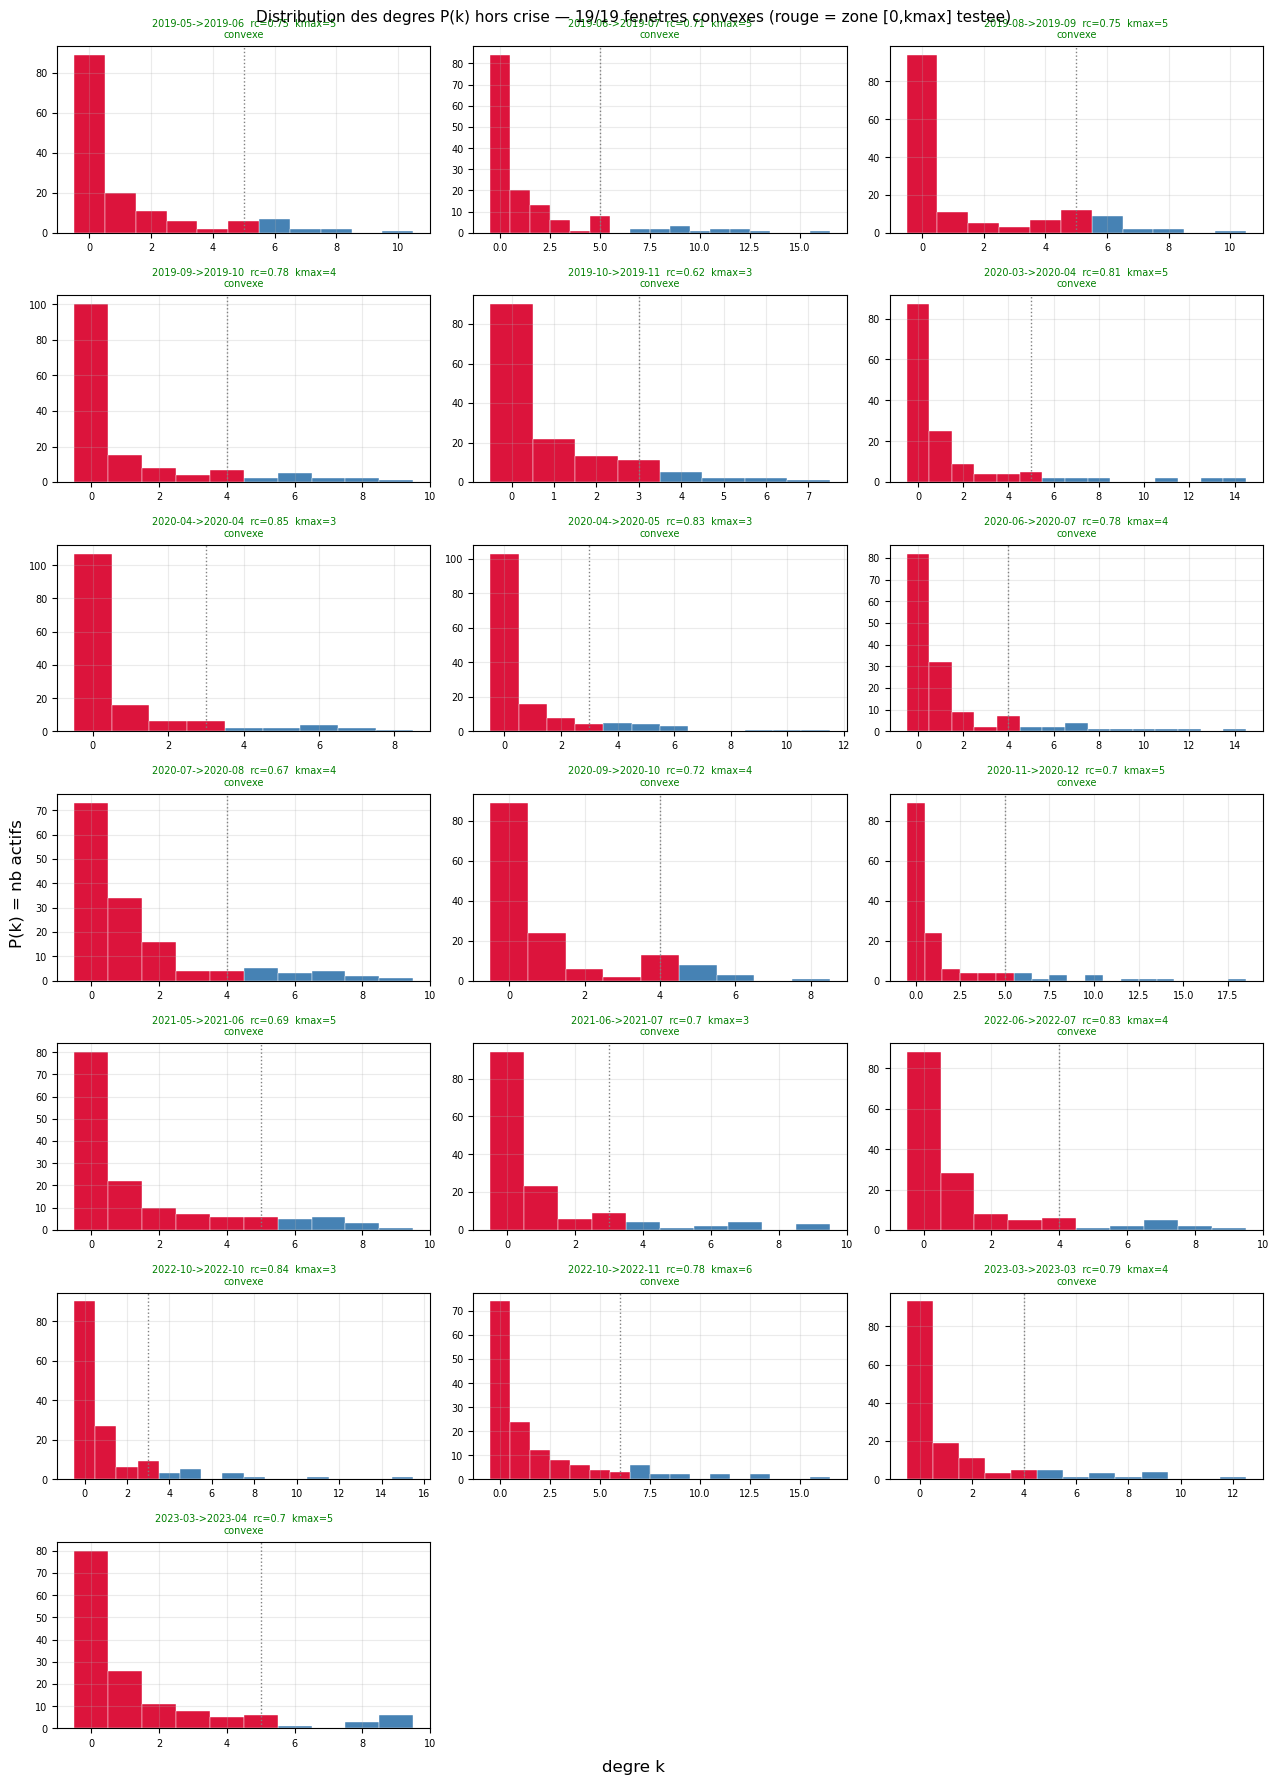

19/19 fenetres hors crise convexes au seuil scale-free


In [8]:
# Distribution des degres P(k) sur les fenetres HORS crise (controle de convexite)
# Decoupage : fenetres de longueur = duree mediane des montees, sans recouvrir une bande de crise.
Lm = int(np.median([b - a for a, b in peak_rises]))
bands = [(a, b) for a, b in peak_rises]
calm_wins, s = [], 0
while s + Lm < len(all_days):
    e = s + Lm
    if not any(a <= e and s <= b for a, b in bands):   # aucun recouvrement avec une montee
        calm_wins.append((s, e))
    s += Lm

n = len(calm_wins); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.6 * nrow)); axes = axes.ravel()
n_convex = 0
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for j, (pa, pb) in enumerate(calm_wins):
        d0, d1 = all_days[pa], all_days[pb]
        C = _corr_window(d0, d1); rc = scale_free_threshold(C); deg = _degrees(C, rc)
        counts = np.bincount(deg, minlength=int(deg.max()) + 1).astype(float)
        kmax = int(np.quantile(deg, 0.9)); k = np.arange(len(counts))
        seg = counts[:kmax + 1]
        convex = (kmax < 2) or np.all(np.diff(seg, 2) >= 0)
        n_convex += int(convex)
        ax = axes[j]
        ax.bar(k, counts, width=1.0, color='steelblue', edgecolor='white', lw=0.3)
        ax.bar(k[:kmax + 1], seg, width=1.0, color='crimson', edgecolor='white', lw=0.3)  # zone testee
        ax.axvline(kmax, color='gray', ls=':', lw=1)
        tag = 'convexe' if convex else 'NON convexe'
        ax.set_title(f'{str(d0)[:7]}->{str(d1)[:7]}  rc={rc}  kmax={kmax}\n{tag}',
                     fontsize=7, color='green' if convex else 'darkred')
        ax.grid(alpha=0.25); ax.tick_params(labelsize=7)
for kk in range(n, len(axes)):
    axes[kk].axis('off')
fig.supxlabel('degre k'); fig.supylabel('P(k) = nb actifs')
fig.suptitle(f'Distribution des degres P(k) hors crise — {n_convex}/{n} fenetres convexes '
             f'(rouge = zone [0,kmax] testee)', fontsize=11)
plt.tight_layout(); plt.show()
print(f'{n_convex}/{n} fenetres hors crise convexes au seuil scale-free')

## 2. Signaux réseau dans le temps

λ_max/⟨λ⟩ (normalisé) et ⟨|C_ij|⟩ (normalisé) sur l'axe gauche, ⟨r⟩ (rendement moyen) sur l'axe droit. Bandes orange = montées de crise (détection `monthly_correlations`). **Sans** les marqueurs de pics de λ.

In [9]:
# Superposition : clustering + λ_max/⟨λ⟩ + ⟨|C|⟩ (normalisés), ⟨r⟩ à droite
# On annote le coefficient de corrélation de Pearson R entre chaque signal réseau
# et le rendement moyen ⟨r⟩ (séries réalignées sur la même grille temporelle).
def _pearsonR(x_sig, y_sig, x_r, y_r):
    """R de Pearson entre un signal (x_sig, y_sig) et ⟨r⟩ (x_r, y_r) réaligné par interpolation."""
    xs = mdates.date2num(np.asarray(x_sig)); xr = mdates.date2num(np.asarray(x_r))
    yr = np.interp(xs, xr, y_r)                       # ⟨r⟩ ramené sur la grille du signal
    m = np.isfinite(y_sig) & np.isfinite(yr)
    return np.corrcoef(np.asarray(y_sig)[m], yr[m])[0, 1] if m.sum() > 2 else np.nan

R_eig  = _pearsonR(diag_x, diag['ratio_eig'], diag_x, diag['mean_return'])
R_corr = _pearsonR(diag_x, diag['mean_corr'], diag_x, diag['mean_return'])
R_clus = _pearsonR(cdates, clus_disp,        diag_x, diag['mean_return'])

"""
fig, ax = plt.subplots(figsize=(14, 4.8))
ax.plot(diag_x, diag['ratio_eig'] / np.nanmax(diag['ratio_eig']), color='crimson', lw=1.2,
        label=fr'$\lambda_{{max}}/\langle\lambda\rangle$ (norm.)  [R(⟨r⟩)={R_eig:+.2f}]')
ax.plot(diag_x, diag['mean_corr'] / np.nanmax(diag['mean_corr']), color='navy', lw=1.0, alpha=0.8,
        label=fr'$\langle|C_{{ij}}|\rangle$ (norm.)  [R(⟨r⟩)={R_corr:+.2f}]')
ax.plot(cdates, clus_disp / np.nanmax(clus_disp), color='darkgreen', lw=1.8,
        label=f'clustering (lissé 5 j, norm.)  [R(⟨r⟩)={R_clus:+.2f}]')
ax.set_ylabel('signaux réseau (normalisés)'); ax.grid(alpha=0.25)
axb = ax.twinx()
axb.plot(diag_x, diag['mean_return'], color='tab:green', lw=0.9, alpha=0.55, label=r'$\langle r\rangle$')
axb.axhline(0, color='tab:green', lw=0.4, ls=':'); axb.set_ylabel(r'$\langle r\rangle$', color='tab:green')
axb.tick_params(axis='y', labelcolor='tab:green')
for (pa, pb) in peak_rises:
    ax.axvspan(all_days[pa], all_days[pb], color='orange', alpha=0.12)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right')
ax.set_title('Clustering vs λ_max/⟨λ⟩, ⟨|C_ij|⟩, ⟨r⟩ (normalisés) — '
             'R = corrélation de chaque signal avec ⟨r⟩ ; bandes = montées de crise')
plt.tight_layout(); plt.show()
"""

"\nfig, ax = plt.subplots(figsize=(14, 4.8))\nax.plot(diag_x, diag['ratio_eig'] / np.nanmax(diag['ratio_eig']), color='crimson', lw=1.2,\n        label=fr'$\\lambda_{{max}}/\\langle\\lambda\rangle$ (norm.)  [R(⟨r⟩)={R_eig:+.2f}]')\nax.plot(diag_x, diag['mean_corr'] / np.nanmax(diag['mean_corr']), color='navy', lw=1.0, alpha=0.8,\n        label=fr'$\\langle|C_{{ij}}|\rangle$ (norm.)  [R(⟨r⟩)={R_corr:+.2f}]')\nax.plot(cdates, clus_disp / np.nanmax(clus_disp), color='darkgreen', lw=1.8,\n        label=f'clustering (lissé 5 j, norm.)  [R(⟨r⟩)={R_clus:+.2f}]')\nax.set_ylabel('signaux réseau (normalisés)'); ax.grid(alpha=0.25)\naxb = ax.twinx()\naxb.plot(diag_x, diag['mean_return'], color='tab:green', lw=0.9, alpha=0.55, label=r'$\\langle r\rangle$')\naxb.axhline(0, color='tab:green', lw=0.4, ls=':'); axb.set_ylabel(r'$\\langle r\rangle$', color='tab:green')\naxb.tick_params(axis='y', labelcolor='tab:green')\nfor (pa, pb) in peak_rises:\n    ax.axvspan(all_days[pa], all_days[pb], color='oran

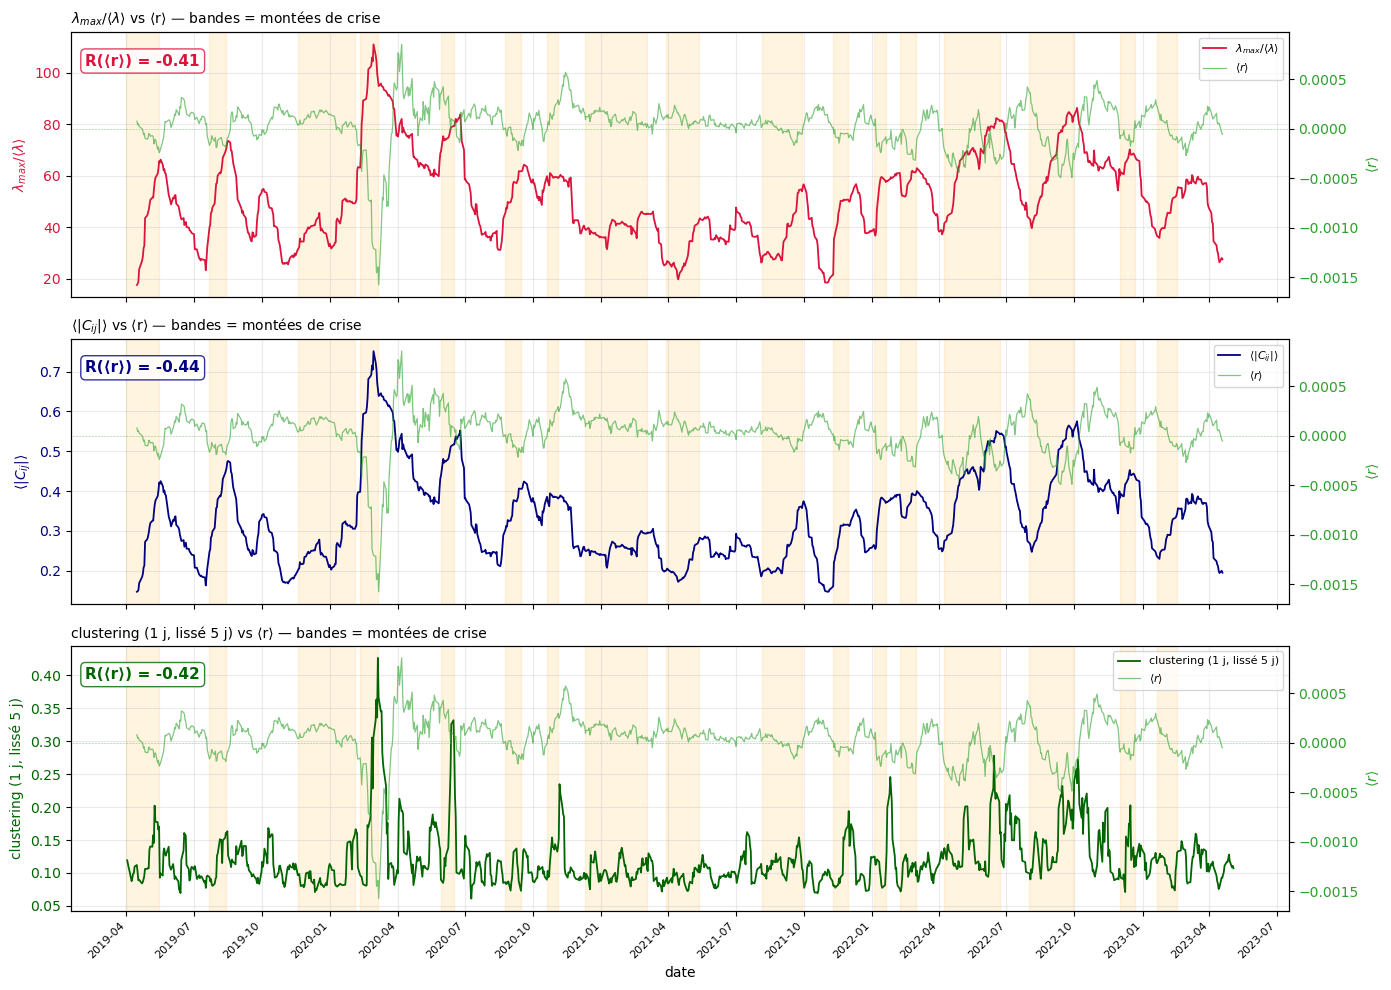

In [10]:
# ⟨r⟩ (log-return moyen) superposé tour à tour à chaque grandeur réseau
# 3 panneaux : grandeur sur l'axe gauche, ⟨r⟩ sur l'axe droit (vert).
# R = coefficient de corrélation de Pearson entre la grandeur et ⟨r⟩ (annoté en haut à gauche).
panels = [
    (diag_x, diag['ratio_eig'],  'crimson',   r'$\lambda_{max}/\langle\lambda\rangle$', R_eig),
    (diag_x, diag['mean_corr'],  'navy',      r'$\langle|C_{ij}|\rangle$',                R_corr),
    (cdates, clus_disp,          'darkgreen', 'clustering (1 j, lissé 5 j)',               R_clus),
]
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, (x, y, color, lab, R) in zip(axes, panels):
    ax.plot(x, y, color=color, lw=1.3, label=lab)
    ax.set_ylabel(lab, color=color); ax.tick_params(axis='y', labelcolor=color)
    ax.grid(alpha=0.25)
    ax.text(0.012, 0.92, f'R(⟨r⟩) = {R:+.2f}', transform=ax.transAxes, fontsize=11,
            fontweight='bold', color=color, va='top',
            bbox=dict(boxstyle='round', fc='white', ec=color, alpha=0.8))
    axb = ax.twinx()
    axb.plot(diag_x, diag['mean_return'], color='tab:green', lw=0.9, alpha=0.6, label=r'$\langle r\rangle$')
    axb.axhline(0, color='tab:green', lw=0.4, ls=':'); axb.set_ylabel(r'$\langle r\rangle$', color='tab:green')
    axb.tick_params(axis='y', labelcolor='tab:green')
    for (pa, pb) in peak_rises:
        ax.axvspan(all_days[pa], all_days[pb], color='orange', alpha=0.12)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right')
    ax.set_title(f'{lab} vs ⟨r⟩ — bandes = montées de crise', fontsize=10, loc='left')
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[-1].set_xlabel('date')
plt.tight_layout(); plt.show()

## 3. (B, R) — inclusion entre méthodes & ratio qui maximise le R² agrégé

Deux questions :

1. **À B=R=1, les 4 méthodes désignent-elles les mêmes actifs ?** Test d'**inclusion** : la méthode qui en retient le moins est-elle un **sous-ensemble** des autres (noyau emboîté) ?
2. **Quel (B, R) maximise le R² agrégé** ? On reprend l'objectif de l'autre notebook, **`agg_r2_sel`** = R² du nuage poolé E_i ↔ x_i restreint aux fits **R²>seuil**. Attention : `agg_r2_sel` n'est **pas** invariant par ratio (le sous-ensemble sélectionné bouge avec B, R), contrairement à `agg_r2_all` (sur tous les fits, lui invariant). On balaie donc une **grille 2D élargie** (B bas, R haut).

Puis on vérifie si les actifs retenus à **B=R=1 sont conservés** à cet optimum — par méthode et par actif.

> Calcul en cache (`br_grid2d_pk`) : intégration SIS parallélisée sur les 17 montées × grille (B, R).

In [11]:
import os
from joblib import Parallel, delayed
from cache import disk_cache, sig_of

# Grille 2D ELARGIE (B bas, R haut) pour retrouver le coin agg_r2_sel de l'autre notebook,
# + 2 points diagonaux pour la demo d'invariance. On calcule DEUX R2 agreges (nuage poolé E↔x) :
#   agg_all = sur tous les fits ; agg_sel = sur les fits R²>seuil (objectif de l'autre notebook).
B_GRID = [0.2, 0.6, 1.0]
R_GRID = [1.0, 1.8, 2.6, 3.0]
PTS = [(round(b, 2), round(r, 2)) for b in B_GRID for r in R_GRID] + [(0.8, 0.8), (1.2, 1.2)]

def _grid_one(cache, B, R):
    """Par méthode/fenêtre : (E,x poolés tous), (E,x poolés sélectionnés), set R²>seuil."""
    out = {m: ([], [], [], [], set()) for m in config.SIS_MODELS}
    for gi, d in cache.items():
        E_i = d['E_i']; ok = ~np.isnan(E_i)
        if ok.sum() < 3:
            continue
        for m in config.SIS_MODELS:
            xt = sis.integrate_fast(d, gi, ctx.A_sis[m], B=B, R=R)
            E, X = E_i[ok], xt[ok]
            Ea, Xa, Es, Xs, S = out[m]
            Ea.append(E); Xa.append(X)
            if linregress(E, X).rvalue ** 2 > config.R2_SEUIL:
                Es.append(E); Xs.append(X); S.add(gi)
    return out

def _agg(Ed, Xd):
    return float(linregress(np.concatenate(Ed), np.concatenate(Xd)).rvalue ** 2) if Ed else np.nan

def _compute_grid():
    tasks = [(p, (pa, pb)) for p in PTS for (pa, pb) in peak_rises]
    parts = Parallel(n_jobs=min(len(tasks), os.cpu_count()))(
        delayed(_grid_one)(peak_pd[(pa, pb)][0], *p) for (p, (pa, pb)) in tasks)
    sets = {p: {m: set() for m in config.SIS_MODELS} for p in PTS}
    poolA = {p: {m: ([], []) for m in config.SIS_MODELS} for p in PTS}
    poolS = {p: {m: ([], []) for m in config.SIS_MODELS} for p in PTS}
    for (p, _), part in zip(tasks, parts):
        for m in config.SIS_MODELS:
            Ea, Xa, Es, Xs, S = part[m]
            poolA[p][m][0].extend(Ea); poolA[p][m][1].extend(Xa)
            poolS[p][m][0].extend(Es); poolS[p][m][1].extend(Xs); sets[p][m] |= S
    agg_all = {p: {m: _agg(*poolA[p][m]) for m in config.SIS_MODELS} for p in PTS}
    agg_sel = {p: {m: _agg(*poolS[p][m]) for m in config.SIS_MODELS} for p in PTS}
    return dict(agg_all=agg_all, agg_sel=agg_sel, sets=sets)

_sig = 'brgrid2d_' + sig_of(repr(sorted(peak_rises)), repr(PTS), str(config.R2_SEUIL))
GRID = disk_cache('br_grid2d_pk', _sig, _compute_grid)
agg_all, agg_sel, br_sets = GRID['agg_all'], GRID['agg_sel'], GRID['sets']
ref_sets = br_sets[(1.0, 1.0)]                       # actifs retenus à B=R=1, par méthode
print('grille (B,R) :', PTS)

[cache] OK  br_grid2d_pk
grille (B,R) : [(0.2, 1.0), (0.2, 1.8), (0.2, 2.6), (0.2, 3.0), (0.6, 1.0), (0.6, 1.8), (0.6, 2.6), (0.6, 3.0), (1.0, 1.0), (1.0, 1.8), (1.0, 2.6), (1.0, 3.0), (0.8, 0.8), (1.2, 1.2)]


=== (1) B=R=1 : tailles et inclusion entre methodes ===
  VAR(1)    :  61 actifs
  PMFG      :  64 actifs
  Corr thr  :  65 actifs
  VAR(13)   :  68 actifs

La plus petite (VAR(1), 61 actifs) est-elle incluse dans les autres ?
  VAR(1) ⊆ PMFG ? False   (manquants : [55, 63, 122])
  VAR(1) ⊆ VAR(13) ? False   (manquants : [120, 122])
  VAR(1) ⊆ Corr thr ? False   (manquants : [15, 47, 122, 127])

Noyau commun aux 4 : 54 actifs ; union : 72 ; noyau/union = 75%

=== (2) agg_r2_sel : invariance diagonale (sur agg_all) + (B,R) qui le maximise ===
Invariance diagonale sur agg_all (tous les fits ; theorie : nul) :
  (B,R)=(0.8, 0.8) : |Δ agg_all| max vs (1,1) = 2.6e-04
  (B,R)=(1.2, 1.2) : |Δ agg_all| max vs (1,1) = 3.0e-04

(B,R) qui maximise agg_r2_sel, par methode (ratio R/B) :
  PMFG      : (B,R)=(0.6, 2.6)  R/B= 4.3  agg_sel=0.6356  (B=R=1 : 0.5585)
  VAR(1)    : (B,R)=(0.2, 3.0)  R/B=15.0  agg_sel=0.6440  (B=R=1 : 0.5322)
  VAR(13)   : (B,R)=(0.2, 1.8)  R/B= 9.0  agg_sel=0.6466  (B=R=1 

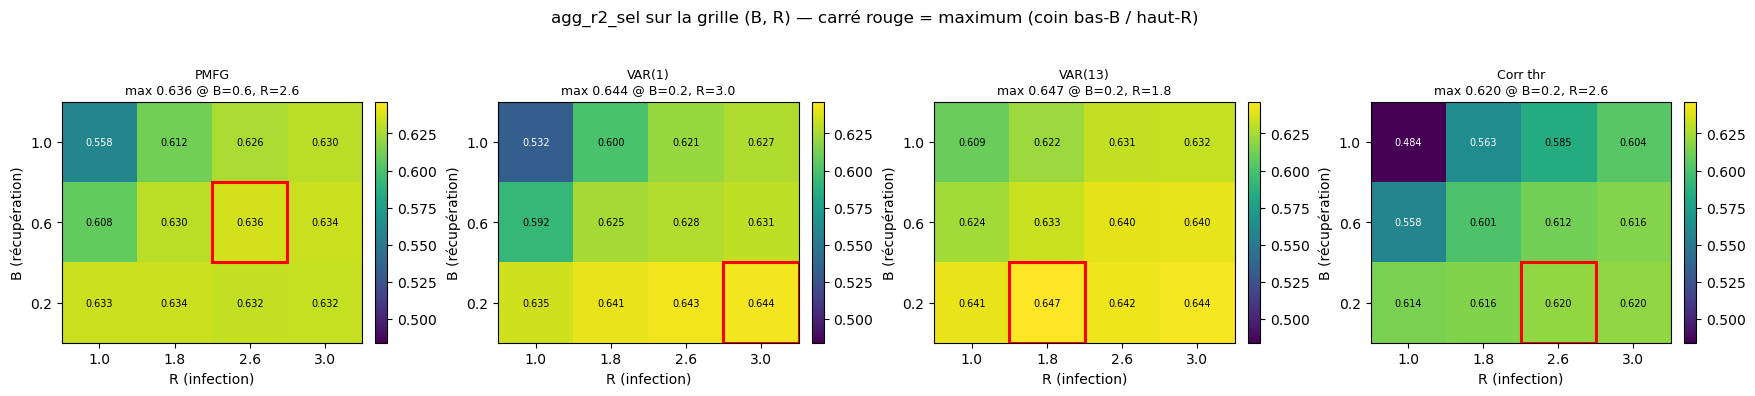

In [12]:
from matplotlib.patches import Rectangle

# (1) A B=R=1 : les 4 methodes designent-elles les memes actifs ? -> test d'inclusion
print('=== (1) B=R=1 : tailles et inclusion entre methodes ===')
order = sorted(config.SIS_MODELS, key=lambda m: len(ref_sets[m]))
for m in order:
    print(f'  {m:10s}: {len(ref_sets[m]):3d} actifs')
small = order[0]
print(f'\nLa plus petite ({small}, {len(ref_sets[small])} actifs) est-elle incluse dans les autres ?')
for m in config.SIS_MODELS:
    if m == small:
        continue
    miss = ref_sets[small] - ref_sets[m]
    print(f'  {small} ⊆ {m} ? {ref_sets[small] <= ref_sets[m]}   (manquants : {sorted(miss) if miss else "aucun"})')
inter = set.intersection(*ref_sets.values()); union = set().union(*ref_sets.values())
print(f'\nNoyau commun aux 4 : {len(inter)} actifs ; union : {len(union)} ; '
      f'noyau/union = {100*len(inter)/max(1,len(union)):.0f}%')

# (2) agg_r2_sel (objectif de l'autre notebook) : invariance (sur agg_all) + (B,R) optimal
print('\n=== (2) agg_r2_sel : invariance diagonale (sur agg_all) + (B,R) qui le maximise ===')
print('Invariance diagonale sur agg_all (tous les fits ; theorie : nul) :')
for p in [(0.8, 0.8), (1.2, 1.2)]:
    dmax = max(abs(agg_all[p][m] - agg_all[(1.0, 1.0)][m]) for m in config.SIS_MODELS)
    print(f'  (B,R)={p} : |Δ agg_all| max vs (1,1) = {dmax:.1e}')
opt = {m: max((p for p in PTS if not np.isnan(agg_sel[p][m])), key=lambda p: agg_sel[p][m])
       for m in config.SIS_MODELS}
print('\n(B,R) qui maximise agg_r2_sel, par methode (ratio R/B) :')
for m in config.SIS_MODELS:
    B, R = opt[m]
    print(f'  {m:10s}: (B,R)={opt[m]}  R/B={R/B:4.1f}  agg_sel={agg_sel[opt[m]][m]:.4f}  '
          f'(B=R=1 : {agg_sel[(1.0, 1.0)][m]:.4f})')

# (3) Les actifs B=R=1 sont-ils conserves a cet optimum (par methode) ?
print('\n=== (3) B=R=1 conserve a l\'optimum agg_sel (par methode) ===')
for m in config.SIS_MODELS:
    r, s = ref_sets[m], br_sets[opt[m]][m]
    print(f'  {m:10s}: B=R=1 {len(r):3d} -> opt{opt[m]} {len(s):3d} ; '
          f'conserves {len(r & s)}/{len(r)} ; ajoutes {len(s - r)} ; retires {len(r - s)} ; '
          f'B=R=1 ⊆ opt ? {r <= s}')

# (4) Optimum PAR ACTIF : retenu pour au moins un (B,R) de la grille (B=R=1 inclus -> on lit les ajouts)
print('\n=== (4) Optimum par actif (retenu pour >=1 (B,R)) ===')
for m in config.SIS_MODELS:
    any_set = set().union(*(br_sets[p][m] for p in PTS))
    print(f'  {m:10s}: B=R=1 {len(ref_sets[m]):3d} -> par-actif {len(any_set):3d} ; ajoutes {len(any_set - ref_sets[m])}')

# Meshgrid agg_r2_sel sur la grille reguliere B x R (1 carte par methode, max encadre en rouge)
vmin = min(agg_sel[(b, r)][m] for b in B_GRID for r in R_GRID for m in config.SIS_MODELS)
vmax = max(agg_sel[(b, r)][m] for b in B_GRID for r in R_GRID for m in config.SIS_MODELS)
fig, axes = plt.subplots(1, len(config.SIS_MODELS), figsize=(4.4 * len(config.SIS_MODELS), 4.0))
for ax, m in zip(np.atleast_1d(axes), config.SIS_MODELS):
    M = np.array([[agg_sel[(b, r)][m] for r in R_GRID] for b in B_GRID])   # lignes=B, colonnes=R
    im = ax.imshow(M, origin='lower', aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(R_GRID))); ax.set_xticklabels(R_GRID)
    ax.set_yticks(range(len(B_GRID))); ax.set_yticklabels(B_GRID)
    ax.set_xlabel('R (infection)'); ax.set_ylabel('B (récupération)')
    for i in range(len(B_GRID)):
        for j in range(len(R_GRID)):
            ax.text(j, i, f'{M[i, j]:.3f}', ha='center', va='center', fontsize=7,
                    color='white' if M[i, j] < (vmin + vmax) / 2 else 'black')
    bi, rj = np.unravel_index(np.argmax(M), M.shape)
    ax.add_patch(Rectangle((rj - 0.5, bi - 0.5), 1, 1, fill=False, edgecolor='red', lw=2.2))
    ax.set_title(f'{m}\nmax {M.max():.3f} @ B={B_GRID[bi]}, R={R_GRID[rj]}', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('agg_r2_sel sur la grille (B, R) — carré rouge = maximum (coin bas-B / haut-R)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

In [13]:
# Recap a l'optimum agg_sel PROPRE A CHAQUE METHODE (B,R different par methode).
# br_sets ne stocke que l'union -> ensembles PAR periode recalcules (cache opt_sets_pm).
from cache import disk_cache, sig_of
opt_br = {m: max((p for p in PTS if not np.isnan(agg_sel[p][m])), key=lambda p: agg_sel[p][m])
          for m in config.SIS_MODELS}                      # argmax agg_sel par methode
print('B et R optimal (max agg_r2_sel) par methode :')
for m in config.SIS_MODELS:
    print(f'  {m:10s}: B={opt_br[m][0]}, R={opt_br[m][1]}')

def _ret_pm_br(cache, m, B, R):
    s = set()
    for gi, d in cache.items():
        E_i = d['E_i']; ok = ~np.isnan(E_i)
        if ok.sum() < 3:
            continue
        xt = sis.integrate_fast(d, gi, ctx.A_sis[m], B=B, R=R)
        if linregress(E_i[ok], xt[ok]).rvalue ** 2 > config.R2_SEUIL:
            s.add(gi)
    return s

def _compute_opt_sets():
    return {(pa, pb): {m: _ret_pm_br(peak_pd[(pa, pb)][0], m, *opt_br[m]) for m in config.SIS_MODELS}
            for (pa, pb) in peak_rises}

_sig = 'optsets_' + sig_of(repr(sorted(peak_rises)), repr(sorted(opt_br.items())), str(config.R2_SEUIL))
opt_sets_pm = disk_cache('opt_sets_pm', _sig, _compute_opt_sets)

# communs(4) = actifs retenus par les 4 methodes, CHACUNE a son (B,R) optimal
rows = []
for (pa, pb) in peak_rises:
    sets_p = opt_sets_pm[(pa, pb)]
    union_p = set().union(*sets_p.values())
    if not union_p:
        continue
    inter_p = set.intersection(*sets_p.values())
    row = {'periode': f'{str(all_days[pa])[:10]} -> {str(all_days[pb])[:10]}'}
    for m in config.SIS_MODELS:
        row[m] = len(sets_p[m])
    row['union'] = len(union_p)
    row['communs(4)'] = len(inter_p)
    row['%commun(4)'] = round(100 * len(inter_p) / len(union_p), 0)
    rows.append(row)

glob = {m: set().union(*(opt_sets_pm[w][m] for w in peak_rises)) for m in config.SIS_MODELS}
g_union = set().union(*glob.values()); g_inter = set.intersection(*glob.values())
row = {'periode': 'GLOBAL (union periodes)'}
for m in config.SIS_MODELS:
    row[m] = len(glob[m])
row['union'] = len(g_union)
row['communs(4)'] = len(g_inter)
row['%commun(4)'] = round(100 * len(g_inter) / max(1, len(g_union)), 0)
rows.append(row)

recap_opt = pd.DataFrame(rows).rename(
    columns={m: f'{m} (B{opt_br[m][0]},R{opt_br[m][1]})' for m in config.SIS_MODELS})
print('\n--- Tableau a (B,R) OPTIMAL par methode ---')
display(recap_opt)
print(f"GLOBAL @opt : {len(g_inter)} communs aux 4 (chacune a son B,R) / {len(g_union)} (union) "
      f"= {100*len(g_inter)/max(1,len(g_union)):.0f}%")

B et R optimal (max agg_r2_sel) par methode :
  PMFG      : B=0.6, R=2.6
  VAR(1)    : B=0.2, R=3.0
  VAR(13)   : B=0.2, R=1.8
  Corr thr  : B=0.2, R=2.6
[cache] OK  opt_sets_pm

--- Tableau a (B,R) OPTIMAL par methode ---


,periode,"PMFG (B0.6,R2.6)","VAR(1) (B0.2,R3.0)","VAR(13) (B0.2,R1.8)","Corr thr (B0.2,R2.6)",union,communs(4),%commun(4)
0,2019-04-01 -> 2019-05-15,15,19,18,16,20,14,70.0
1,2019-07-22 -> 2019-08-14,4,5,4,5,5,3,60.0
2,2020-02-11 -> 2020-03-06,46,42,42,43,47,38,81.0
3,2020-05-29 -> 2020-06-16,4,5,6,5,6,4,67.0
4,2021-08-05 -> 2021-09-29,0,1,1,0,1,0,0.0
5,2022-01-03 -> 2022-01-20,0,2,2,0,2,0,0.0
6,2022-02-08 -> 2022-03-01,1,1,1,0,1,0,0.0
7,2022-04-08 -> 2022-06-22,4,5,5,4,5,4,80.0
8,GLOBAL (union periodes),64,67,69,64,72,58,81.0


GLOBAL @opt : 58 communs aux 4 (chacune a son B,R) / 72 (union) = 81%


In [14]:
# Le MEME tableau mais a B=R=1 PARTOUT (les 4 methodes a B=R=1). Fits canoniques peak_pd.
def _ret_pm_1(pa, pb, m):
    return {gi for gi, sl in peak_pd[(pa, pb)][1][m][1].items() if sl['r2'] > config.R2_SEUIL}

rows = []
for (pa, pb) in peak_rises:
    sets_p = {m: _ret_pm_1(pa, pb, m) for m in config.SIS_MODELS}
    union_p = set().union(*sets_p.values())
    if not union_p:
        continue
    inter_p = set.intersection(*sets_p.values())
    row = {'periode': f'{str(all_days[pa])[:10]} -> {str(all_days[pb])[:10]}'}
    for m in config.SIS_MODELS:
        row[m] = len(sets_p[m])
    row['union'] = len(union_p)
    row['communs(4)'] = len(inter_p)
    row['%commun(4)'] = round(100 * len(inter_p) / len(union_p), 0)
    rows.append(row)

glob = {m: set().union(*(_ret_pm_1(pa, pb, m) for (pa, pb) in peak_rises)) for m in config.SIS_MODELS}
g_union = set().union(*glob.values()); g_inter = set.intersection(*glob.values())
row = {'periode': 'GLOBAL (union periodes)'}
for m in config.SIS_MODELS:
    row[m] = len(glob[m])
row['union'] = len(g_union)
row['communs(4)'] = len(g_inter)
row['%commun(4)'] = round(100 * len(g_inter) / max(1, len(g_union)), 0)
rows.append(row)

recap_br1 = pd.DataFrame(rows)
print('--- Tableau a B=R=1 PARTOUT ---')
display(recap_br1)
print(f"GLOBAL B=R=1 : {len(g_inter)} communs aux 4 / {len(g_union)} (union) "
      f"= {100*len(g_inter)/max(1,len(g_union)):.0f}%")

--- Tableau a B=R=1 PARTOUT ---


,periode,PMFG,VAR(1),VAR(13),Corr thr,union,communs(4),%commun(4)
0,2019-04-01 -> 2019-05-15,14,13,16,16,18,11,61.0
1,2019-07-22 -> 2019-08-14,5,5,5,5,5,5,100.0
2,2020-02-11 -> 2020-03-06,44,42,46,44,48,38,79.0
3,2020-05-29 -> 2020-06-16,5,5,5,5,6,4,67.0
4,2022-01-03 -> 2022-01-20,0,2,2,0,2,0,0.0
5,2022-02-08 -> 2022-03-01,1,0,0,1,1,0,0.0
6,2022-04-08 -> 2022-06-22,4,4,5,4,5,4,80.0
7,GLOBAL (union periodes),64,61,68,65,72,54,75.0


GLOBAL B=R=1 : 54 communs aux 4 / 72 (union) = 75%


**Lecture.**

1. **À B=R=1, les méthodes ne sont PAS emboîtées.** Tailles : VAR(1) 61, PMFG 64, Corr thr 65, VAR(13) 68. La plus petite (VAR(1)) **n'est incluse dans aucune** des autres (il lui manque 2 à 4 actifs propres). Elles partagent un **noyau de 54 actifs** commun aux 4 sur une union de 72 (**75 %**) : large accord, mais chaque méthode garde une poignée d'actifs idiosyncratiques. « Les mêmes actifs » ≈ vrai à 75 %, faux au sens strict de l'inclusion.

2. **L'optimum `agg_r2_sel` est un coin bas-B / haut-R** (ratio R/B élevé), conforme à l'autre notebook : PMFG (0.6, 2.6), VAR(1) (0.2, 3.0), VAR(13) (0.2, 1.8), Corr thr (0.2, 2.6). `agg_r2_sel` y monte nettement (Corr thr 0.48→0.62, VAR(1) 0.53→0.64, ~+0.10 à +0.14). **Mais c'est trompeur** : `agg_r2_sel` n'est pas invariant par ratio — pousser l'infection ré-aligne un sous-ensemble *sélectionné* qui change. Le R² invariant `agg_r2_all` (tous les fits), lui, ne bouge presque pas avec le ratio (diagonale vérifiée à ~3e-4). C'est donc une **optimisation de coin dégénérée**, pas un vrai optimum physique.

3. **À cet optimum, les actifs de B=R=1 ne sont PAS conservés** (⊄ pour les 4 méthodes). Ex. VAR(1) : 61 → 67, mais **6 retirés** et 12 ajoutés ; PMFG 64 → 64 (4 ajoutés, 4 retirés). Le coin rebrasse la sélection (1–6 actifs perdus par méthode), il n'est pas additif.

4. **Optimum par actif** (chaque actif garde son meilleur (B,R) de la grille) : les actifs de B=R=1 sont conservés par construction et on en **gagne** +2 à +12 (surtout VAR(1) : +12) — ceux qui passaient juste sous le seuil à B=R=1.

**Conclusion.** Maximiser `agg_r2_sel` envoie (B, R) dans un coin extrême (B≈0.2, R≈2–3) et y gagne ~+0.1 de R² agrégé, **mais** (a) le R² invariant `agg_r2_all` ne progresse quasiment pas, (b) le coin retire 1–6 actifs de la sélection B=R=1 par méthode. C'est un artefact de l'objectif (R² d'un sous-ensemble mouvant), pas un gain de modèle réel — **B=R=1 reste le choix canonique défendable**, et le noyau de 54 actifs commun aux 4 méthodes est robuste au choix de (B, R).

## 4. Test null — le SIS marche-t-il **hors** crise collective ?

Pour chaque actif **retenu** (R² > 0.6 dans au moins une crise collective), on cherche une **montée individuelle de son E_i en dehors** de toutes les crises collectives (mêmes détecteurs : `asset_runs` sur la carte de crise, puis `strong_rise`), et on y ajuste le SIS. Si le modèle ne marche que sur les crises *collectives*, ces montées hors-crise doivent beaucoup moins bien s'ajuster.

> La construction de E_i / x0 reproduit **exactement** `cache_signed` (corrélations signées par jour) — validé contre les R² en cache. Fits mis en cache (`null_offcrisis`).

In [15]:
from cache import disk_cache, sig_of
from periods import asset_runs, strong_rise

def _build_entry(gi, a, b):
    # Entrée (E_i, x0, n_days) à la manière de cache_signed, sur le run (a, b) de gi.
    res = strong_rise(ctx.E_daily_all[gi, a:b + 1])
    if res is None:
        return None
    A0, B0 = a + res[2], a + res[3]
    days_p = list(ctx.all_days[A0:B0 + 1])
    dp = ctx.data[np.isin(ctx.data.index.date, days_p)].copy(); dp['day'] = dp.index.date
    days_s = sorted(dp['day'].unique()); n_days = len(days_s)
    Es = np.full((N, n_days), np.nan)
    for k, d in enumerate(days_s):
        chunk = dp[dp['day'] == d].drop(columns=['day']).values
        if len(chunk) < 3:
            continue
        C = np.nan_to_num(np.corrcoef(chunk.T), nan=0.0); np.fill_diagonal(C, 0)
        Es[:, k] = C.sum(axis=1) / (N - 1)
    valid = np.where(np.any(~np.isnan(Es), axis=0))[0]
    if len(valid) == 0:
        return None
    return dict(E_i=Es[gi], x0=Es[:, valid[0]], n_days=n_days)

def _overlaps_collective(a, b):
    return any(a <= pb and b >= pa for (pa, pb) in peak_rises)

# actifs retenus (union des méthodes) + leurs R² collectifs
selected = set()
coll_r2 = {m: [] for m in config.SIS_MODELS}
for (pa, pb) in peak_rises:
    for m in config.SIS_MODELS:
        for gi, sl in peak_pd[(pa, pb)][1][m][1].items():
            if sl['r2'] > config.R2_SEUIL:
                selected.add(gi)
for (pa, pb) in peak_rises:
    for m in config.SIS_MODELS:
        for gi, sl in peak_pd[(pa, pb)][1][m][1].items():
            if gi in selected:
                coll_r2[m].append(sl['r2'])

def _compute_null():
    null_r2 = {m: [] for m in config.SIS_MODELS}; wins = []
    for gi in sorted(selected):
        for (a, b) in asset_runs(crisis_map[gi]):
            if _overlaps_collective(a, b):
                continue
            d = _build_entry(gi, a, b)
            if d is None:
                continue
            E_i = d['E_i']; ok = ~np.isnan(E_i)
            if ok.sum() < 3:
                continue
            wins.append((gi, a, b))
            for m in config.SIS_MODELS:
                xt = sis.integrate(d, gi, ctx.A_sis[m])
                null_r2[m].append(linregress(E_i[ok], xt[ok]).rvalue ** 2)
    return dict(null_r2=null_r2, wins=wins)

_sig = 'off_' + sig_of(repr(sorted(selected)), repr(sorted(peak_rises)), str(config.R2_SEUIL))
null = disk_cache('null_offcrisis', _sig, _compute_null)
null_r2 = null['null_r2']
print(f'{len(selected)} actifs retenus  ->  {len(null["wins"])} montées individuelles hors crise collective')

[cache] OK  null_offcrisis
72 actifs retenus  ->  35 montées individuelles hors crise collective


,methode,% R²>0.6 EN crise,% R²>0.6 HORS crise,ratio (en/hors),n (crise),n (hors),R²méd (crise),R²méd (hors)
0,PMFG,18.5,8.6,2.2,395,35,0.256,0.337
1,VAR(1),18.0,5.7,3.1,395,35,0.248,0.344
2,VAR(13),20.0,8.6,2.3,395,35,0.261,0.343
3,Corr thr,19.0,8.6,2.2,395,35,0.263,0.336


>>> À COMPARER (poolé 4 méthodes) : 18.9 % des fits R²>0.6 EN crise collective contre 7.9 % HORS crise  ->  ratio x2.4


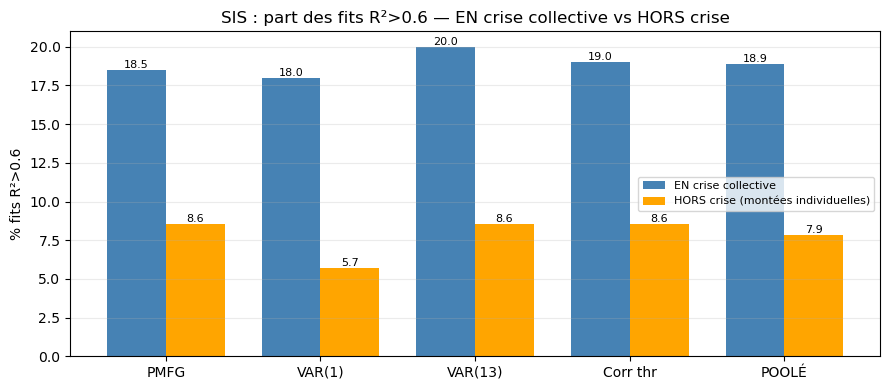

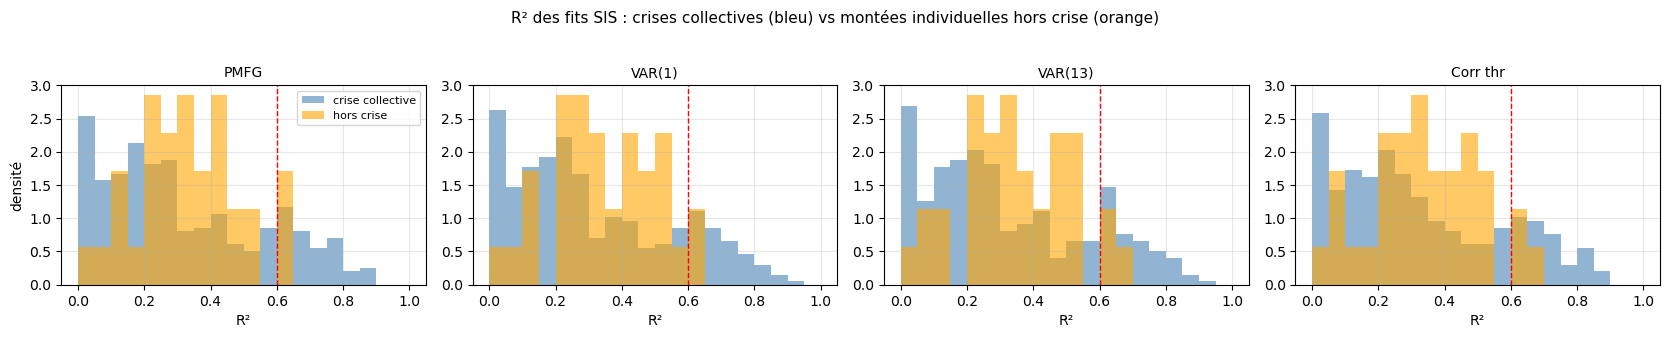

In [16]:
# Comparaison-clé : part des fits SIS R²>0.6 EN crise collective vs HORS crise collective.
# C'est *ce* contraste (≈ 18-20 % vs ≈ 6-9 %) qui porte le message ; les autres colonnes
# (n, R² médian) sont accessoires et reléguées en fin de tableau.
rows = []
for m in config.SIS_MODELS:
    c = np.array(coll_r2[m]); nc = np.array(null_r2[m])
    pc, ph = 100 * np.mean(c > config.R2_SEUIL), 100 * np.mean(nc > config.R2_SEUIL)
    rows.append({'methode': m,
                 '% R²>0.6 EN crise': round(pc, 1),
                 '% R²>0.6 HORS crise': round(ph, 1),
                 'ratio (en/hors)': round(pc / ph, 1) if ph else np.inf,
                 'n (crise)': len(c), 'n (hors)': len(nc),
                 'R²méd (crise)': round(float(np.median(c)), 3),
                 'R²méd (hors)': round(float(np.median(nc)), 3)})
tab4 = pd.DataFrame(rows)
display(tab4)

# Chiffre poolé (toutes méthodes) : les deux pourcentages à comparer.
allc = np.concatenate([np.array(coll_r2[m]) for m in config.SIS_MODELS])
alln = np.concatenate([np.array(null_r2[m]) for m in config.SIS_MODELS])
p_coll, p_hors = 100 * np.mean(allc > config.R2_SEUIL), 100 * np.mean(alln > config.R2_SEUIL)
print(f'>>> À COMPARER (poolé 4 méthodes) : {p_coll:.1f} % des fits R²>0.6 EN crise collective '
      f'contre {p_hors:.1f} % HORS crise  ->  ratio x{p_coll/p_hors:.1f}')

# Barres : les deux pourcentages côte à côte, par méthode + poolé.
labels = config.SIS_MODELS + ['POOLÉ']
en   = [100 * np.mean(np.array(coll_r2[m]) > config.R2_SEUIL) for m in config.SIS_MODELS] + [p_coll]
hors = [100 * np.mean(np.array(null_r2[m]) > config.R2_SEUIL) for m in config.SIS_MODELS] + [p_hors]
x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - w/2, en,   w, color='steelblue', label='EN crise collective')
b2 = ax.bar(x + w/2, hors, w, color='orange',    label='HORS crise (montées individuelles)')
ax.bar_label(b1, fmt='%.1f', fontsize=8); ax.bar_label(b2, fmt='%.1f', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('% fits R²>0.6')
ax.set_title('SIS : part des fits R²>0.6 — EN crise collective vs HORS crise'); ax.legend(fontsize=8)
ax.grid(alpha=0.25, axis='y'); plt.tight_layout(); plt.show()

# Distribution complète des R² (accessoire mais informatif).
fig, axes = plt.subplots(1, len(config.SIS_MODELS), figsize=(4.2 * len(config.SIS_MODELS), 3.4), squeeze=False)
for j, m in enumerate(config.SIS_MODELS):
    ax = axes[0, j]
    ax.hist(coll_r2[m], bins=np.linspace(0, 1, 21), density=True, color='steelblue', alpha=0.6, label='crise collective')
    ax.hist(null_r2[m], bins=np.linspace(0, 1, 21), density=True, color='orange', alpha=0.6, label='hors crise')
    ax.axvline(config.R2_SEUIL, color='red', ls='--', lw=1)
    ax.set_title(m, fontsize=10); ax.set_xlabel('R²'); ax.grid(alpha=0.3)
    if j == 0:
        ax.set_ylabel('densité'); ax.legend(fontsize=8)
plt.suptitle('R² des fits SIS : crises collectives (bleu) vs montées individuelles hors crise (orange)', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

**Lecture.** Hors des crises collectives, on ne trouve que **~35 montées individuelles** propres (sur 72 actifs retenus, ~380 plages hors-crise) : déjà un signe que la montée nette de E_i est surtout un phénomène **collectif**. Sur ces montées, la part de bons fits (R² > 0.6) tombe à **~6–9 %**, contre **~18–20 %** en crise collective (≈ 2–3× moins). La médiane des R² reste comparable : l'effet porte sur la **queue** (les très bons fits), pas sur le centre. **Conclusion : le SIS ajuste nettement mieux les crises collectives, sans être totalement spécifique** — une partie du « bon fit » reste l'artefact montante-vs-montante (cf. nulls par permutation).

## 5. Actifs retenus par méthode × période + accord entre méthodes

Nombre d'actifs retenus (fit SIS R² > 0.6) **par période de crise et par méthode** de contagion (PMFG, VAR(1), VAR(13), Corr thr), plus l'**union**, le nb d'actifs retenus par **toutes** les méthodes et le **% commun** (intersection / union). On regarde si les 4 méthodes désignent les mêmes actifs.

,periode,PMFG,VAR(1),VAR(13),Corr thr,union,intersection,commun > 3,% intersection,% commun > 3
0,2019-04-01 → 2019-05-15,14,13,16,16,18,11,14,61.1,77.8
1,2019-07-22 → 2019-08-14,5,5,5,5,5,5,5,100.0,100.0
2,2020-02-11 → 2020-03-06,44,42,46,44,48,38,44,79.2,91.7
3,2020-05-29 → 2020-06-16,5,5,5,5,6,4,5,66.7,83.3
4,2022-01-03 → 2022-01-20,0,2,2,0,2,0,0,0.0,0.0
5,2022-02-08 → 2022-03-01,1,0,0,1,1,0,0,0.0,0.0
6,2022-04-08 → 2022-06-22,4,4,5,4,5,4,4,80.0,80.0


GLOBAL (toutes périodes confondues) :
  PMFG       : 64 actifs retenus
  VAR(1)     : 61 actifs retenus
  VAR(13)    : 68 actifs retenus
  Corr thr   : 65 actifs retenus
  UNION (≥1 méthode)      : 72
  INTERSECTION (4 méth.)  :  54  = 75.0 % de l'union
  meilleure ∩ de 3 méth.  :  58  = 80.6 % de l'union
  ≥3 méthodes             :  64  = 88.9 % de l'union
  ≥2 méthodes             :  68  = 94.4 % de l'union


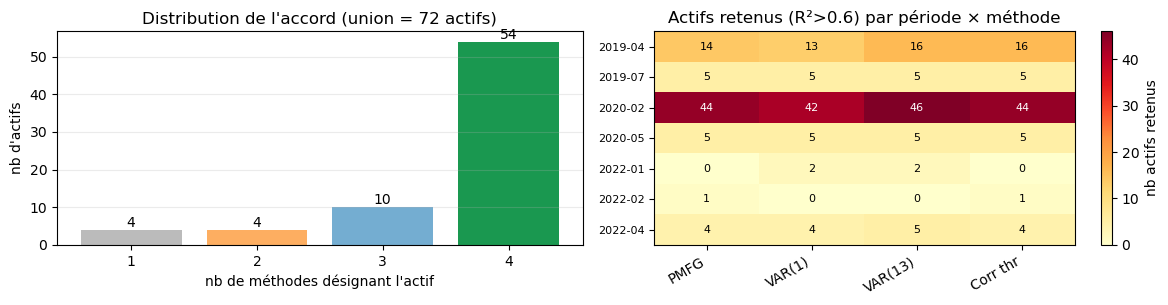

In [17]:
# Ensembles retenus par (période, méthode) à B=R=1 (fits canoniques peak_pd).
from collections import Counter
sel_pm = {}
for (pa, pb) in peak_rises:
    sel_pm[(pa, pb)] = {m: {gi for gi, sl in peak_pd[(pa, pb)][1][m][1].items() if sl['r2'] > config.R2_SEUIL}
                        for m in config.SIS_MODELS}

# on ne garde que les périodes avec au moins un actif retenu (on enlève les zéros partout)
kept = [(pa, pb) for (pa, pb) in peak_rises if set().union(*sel_pm[(pa, pb)].values())]

# Par période : UNION, INTERSECTION(4), accord ≥3 méthodes, et les deux % (∩/∪).
rows = []
for (pa, pb) in kept:
    s = sel_pm[(pa, pb)]; union = set().union(*s.values())
    inter4 = set.intersection(*s.values())
    cnt = Counter(g for m in config.SIS_MODELS for g in s[m])
    ge3 = {g for g, c in cnt.items() if c >= 3}
    row = {'periode': f'{str(all_days[pa])[:10]} → {str(all_days[pb])[:10]}'}
    for m in config.SIS_MODELS:
        row[m] = len(s[m])
    row['union'] = len(union); row['intersection'] = len(inter4); row['commun > 3'] = len(ge3)
    row['% intersection'] = round(100 * len(inter4) / max(1, len(union)), 1)
    row['% commun > 3'] = round(100 * len(ge3) / max(1, len(union)), 1)
    rows.append(row)
tab5 = pd.DataFrame(rows)
display(tab5)

# Global : on agrège chaque méthode sur toutes les périodes, puis on compare UNION vs INTERSECTION.
allsel = {m: set().union(*(sel_pm[w][m] for w in peak_rises)) for m in config.SIS_MODELS}
union = set().union(*allsel.values())
inter4 = set.intersection(*allsel.values())
cnt = Counter(g for m in config.SIS_MODELS for g in allsel[m])      # nb de méthodes par actif
ge3 = {g for g, c in cnt.items() if c >= 3}; ge2 = {g for g, c in cnt.items() if c >= 2}
from itertools import combinations
best3 = max((set.intersection(*(allsel[m] for m in c)) for c in combinations(config.SIS_MODELS, 3)), key=len)
print('GLOBAL (toutes périodes confondues) :')
for m in config.SIS_MODELS:
    print(f'  {m:10s} : {len(allsel[m])} actifs retenus')
print(f'  UNION (≥1 méthode)      : {len(union)}')
print(f'  INTERSECTION (4 méth.)  : {len(inter4):3d}  = {100*len(inter4)/len(union):.1f} % de l\'union')
print(f'  meilleure ∩ de 3 méth.  : {len(best3):3d}  = {100*len(best3)/len(union):.1f} % de l\'union')
print(f'  ≥3 méthodes             : {len(ge3):3d}  = {100*len(ge3)/len(union):.1f} % de l\'union')
print(f'  ≥2 méthodes             : {len(ge2):3d}  = {100*len(ge2)/len(union):.1f} % de l\'union')

# Distribution : combien d'actifs sont désignés par 1, 2, 3 ou 4 méthodes ? (vérif. de l'accord)
dist = Counter(cnt.values())
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, max(2.5, 0.45 * len(kept))))
kk = [1, 2, 3, 4]; vv = [dist.get(k, 0) for k in kk]
bars = axA.bar(kk, vv, color=['#bbb', '#fdae61', '#74add1', '#1a9850'])
axA.bar_label(bars, fmt='%d'); axA.set_xticks(kk)
axA.set_xlabel('nb de méthodes désignant l\'actif'); axA.set_ylabel('nb d\'actifs')
axA.set_title(f'Distribution de l\'accord (union = {len(union)} actifs)')
axA.grid(alpha=0.25, axis='y')

# Heatmap période × méthode (périodes non vides seulement)
M = np.array([[len(sel_pm[(pa, pb)][m]) for m in config.SIS_MODELS] for (pa, pb) in kept])
im = axB.imshow(M, cmap='YlOrRd', aspect='auto')
axB.set_xticks(range(len(config.SIS_MODELS))); axB.set_xticklabels(config.SIS_MODELS, rotation=30, ha='right')
axB.set_yticks(range(len(kept)))
axB.set_yticklabels([f'{str(all_days[pa])[:7]}' for (pa, pb) in kept], fontsize=8)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        axB.text(j, i, M[i, j], ha='center', va='center', fontsize=8,
                 color='black' if M[i, j] < M.max() * 0.6 else 'white')
fig.colorbar(im, ax=axB, label='nb actifs retenus'); axB.set_title('Actifs retenus (R²>0.6) par période × méthode')
plt.tight_layout(); plt.show()

**Lecture.** Les actifs retenus se concentrent dans les **grandes crises collectives** (COVID fév.–mars 2020 : 44–46 par méthode ; avril 2019 : 14–16 ; mai 2020 / avril–juin 2022 : ~5). Beaucoup de montées n'en retiennent **aucun**. Surtout, les 4 méthodes désignent **largement les mêmes actifs** : là où il y a des retenus, le % commun est de 60–100 %, et **globalement ~75 % des actifs retenus le sont par les 4 méthodes**. Le choix de la matrice de contagion (PMFG, VAR, Corr thr) ne change donc presque pas *quels* actifs sont expliqués par le SIS.

## 6. Communautés (Louvain) — les actifs en crise sont-ils regroupés ?

Pour chaque période de crise, on construit le **réseau de corrélations de la période** (méthode `Corr thr`, top 15 % des |C_ij| → graphe connexe), on détecte les **communautés par Louvain**, et on regarde si les **actifs en crise** (détectés sur la période) tombent dans **une même communauté**.

Métrique : part des actifs en crise dans leur communauté **dominante**, comparée à un **tirage aléatoire** d'actifs de même taille (200 tirages). Si crise ≈ aléatoire → pas de regroupement particulier.

In [18]:
from networks import build_filtered_corr
from collections import Counter

# Définition de communauté COMMUNE à tout le §6 (tableau, bar chart, graphes, secteurs) :
# Louvain à résolution PAR DÉFAUT, on retire UNIQUEMENT les communautés de taille 1 (les actions
# isolées, sans corrélation assez forte, que Louvain met chacune seule). On ne touche pas au reste.
def _period_graph(pa, pb):
    obs = (ctx.data.index >= all_days[pa]) & (ctx.data.index <= all_days[pb])
    C = np.abs(np.nan_to_num(np.corrcoef(arr[np.asarray(obs)].T))); np.fill_diagonal(C, 0)
    A = build_filtered_corr(C, config.CORR_THRESHOLD, ctx.mask_off)
    return nx.from_numpy_array(A)

def _graph_comms(pa, pb):
    """Communautés Louvain (résolution par défaut) SANS les communautés de taille 1 (actions isolées).
    Définition unique de communauté pour TOUT le §6."""
    G = _period_graph(pa, pb)
    comm = nx.community.louvain_communities(G, weight='weight', seed=0)
    comm = [c for c in comm if len(c) > 1]                    # enlever les communautés isolées (taille 1)
    G = G.subgraph(set().union(*comm) if comm else set()).copy()
    n2c = {n: ci for ci, c in enumerate(comm) for n in c}
    return G, comm, n2c

# "actifs en crise" = ceux expliques par le SIS (R²>0.6) a leur (B,R) optimal (union des 4 methodes)
def _crisis_opt(pa, pb):
    return set().union(*(opt_sets_pm[(pa, pb)][m] for m in config.SIS_MODELS))

def _crisis_ratio(pa, pb):
    """Par communauté (taille >= 2) : ratio de crise = #actifs en crise / taille.
    Référence = taux de crise parmi les nœuds retenus du graphe (attendu au hasard)."""
    crisis = _crisis_opt(pa, pb)
    G, comm, _ = _graph_comms(pa, pb)
    mod = nx.community.modularity(G, comm, weight='weight') if comm else 0.0
    kept = set().union(*comm) if comm else set()
    base = len(crisis & kept) / len(kept) if kept else 0.0
    ratios = [(len(c), len(c & crisis), len(c & crisis) / len(c)) for c in comm]
    ratios.sort(key=lambda t: -t[2])
    return G, comm, mod, base, ratios

# grandes crises (>= 20 actifs DETECTES) ; n_crise compte les actifs SIS (R²>0.6) a l'optimum.
big = [(pa, pb) for (pa, pb) in peak_rises if len(peak_pd[(pa, pb)][0]) >= 20]
rows = []
for (pa, pb) in big:
    crisis = _crisis_opt(pa, pb)
    if len(crisis) < 2:
        continue
    _, comm, mod, base, ratios = _crisis_ratio(pa, pb)
    rmax = ratios[0][2] if ratios else 0.0
    n_hot = sum(1 for (_, nc, p) in ratios if p > 2 * base and nc >= 2)
    rows.append({'periode': f'{str(all_days[pa])[:10]} -> {str(all_days[pb])[:10]}',
                 'n_crise': len(crisis), 'n_comm': len(comm),
                 '% actifs en crise': round(100 * base, 1),
                 'ratio_crise_max%': round(100 * rmax, 1),
                 'excès_max (pts)': round(100 * (rmax - base), 1),
                 'comm. contaminées (>2x)': n_hot})
tab6 = pd.DataFrame(rows)
display(tab6.set_index('periode'))

print('Ratio d\'actifs en crise par communauté (#crise / taille comm.), trié décroissant :')
for (pa, pb) in big:
    crisis = _crisis_opt(pa, pb)
    if len(crisis) < 2:
        continue
    _, comm, _, base, ratios = _crisis_ratio(pa, pb)
    lst = ', '.join(f'{100*p:.0f}%({nc}/{sz})' for (sz, nc, p) in ratios if p > 0)
    print(f'  {str(all_days[pa])[:10]} ({len(comm)} comm., n_crise={len(crisis)}, '
          f'attendu {100*base:.0f}%) : {lst}')

,n_crise,n_comm,% actifs en crise,ratio_crise_max%,excès_max (pts),comm. contaminées (>2x)
periode,,,,,,
2019-04-01 -> 2019-05-15,20,8,14.0,22.5,8.5,0
2019-07-22 -> 2019-08-14,5,10,3.9,7.5,3.6,0
2020-02-11 -> 2020-03-06,47,5,35.7,66.7,31.0,0
2020-05-29 -> 2020-06-16,6,6,5.2,11.4,6.2,1
2022-01-03 -> 2022-01-20,2,4,1.4,2.9,1.5,0
2022-04-08 -> 2022-06-22,5,8,3.7,5.6,1.8,0


Ratio d'actifs en crise par communauté (#crise / taille comm.), trié décroissant :
  2019-04-01 (8 comm., n_crise=20, attendu 14%) : 22%(9/40), 17%(7/41), 12%(3/26), 5%(1/20)
  2019-07-22 (10 comm., n_crise=5, attendu 4%) : 8%(3/40), 4%(1/23), 2%(1/45)
  2020-02-11 (5 comm., n_crise=47, attendu 36%) : 67%(16/24), 40%(2/5), 34%(13/38), 24%(11/45), 21%(3/14)
  2020-05-29 (6 comm., n_crise=6, attendu 5%) : 11%(5/44), 8%(1/12)
  2022-01-03 (4 comm., n_crise=2, attendu 1%) : 3%(1/35), 2%(1/44)
  2022-04-08 (8 comm., n_crise=5, attendu 4%) : 6%(1/18), 5%(2/38), 4%(1/23), 3%(1/37)


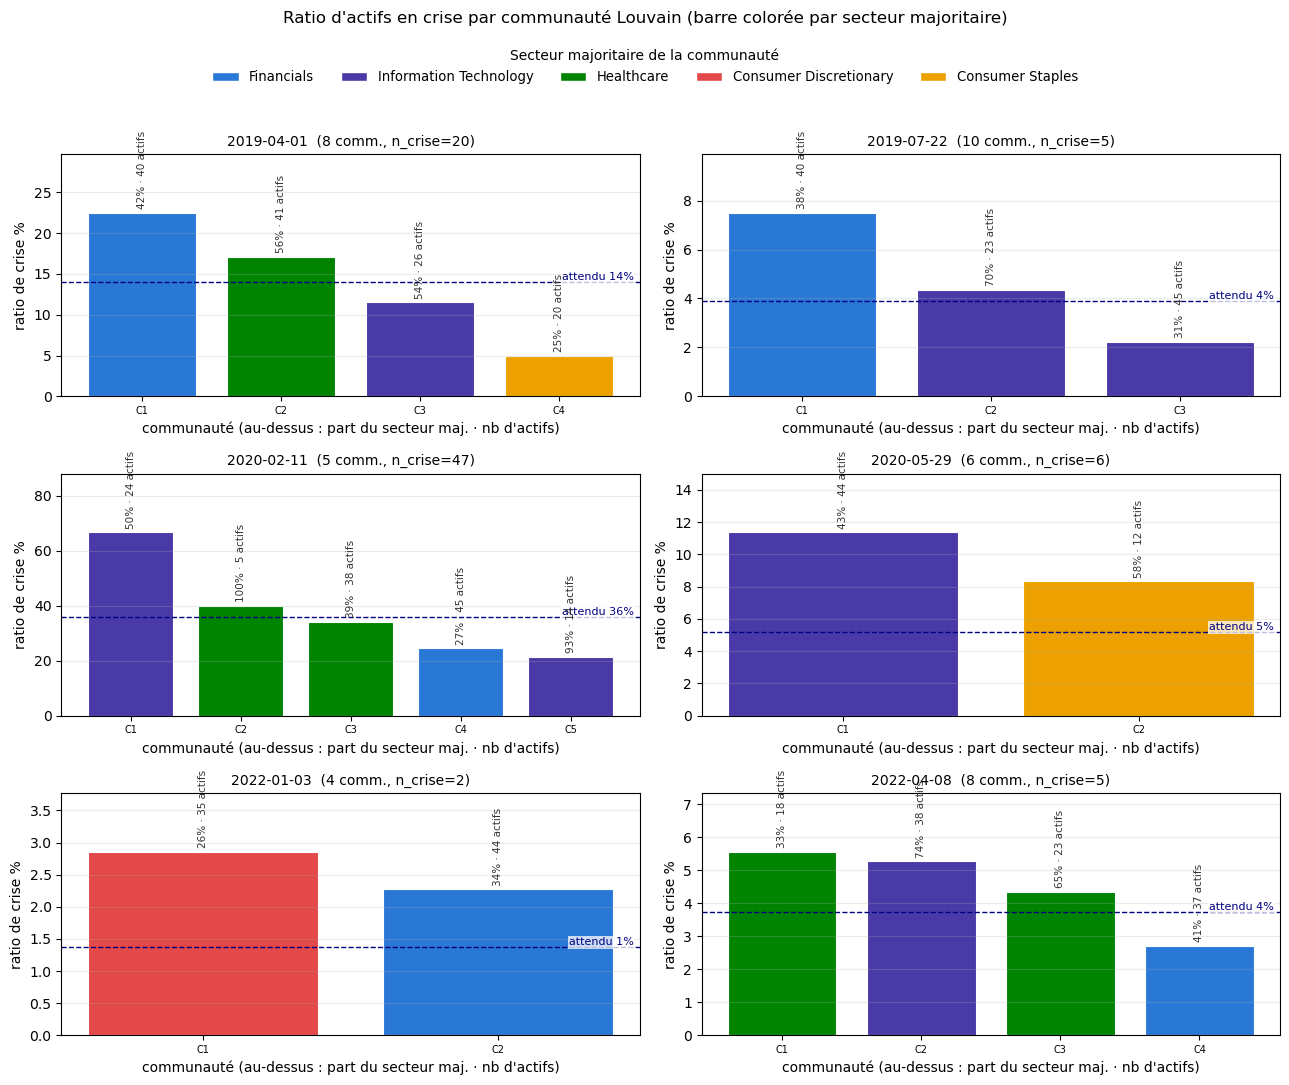

In [19]:
# Visualisation : ratio de crise par communauté pour les grandes crises.
# Une barre = une communauté Louvain ; hauteur = (#actifs en crise)/(taille comm.).
# COULEUR de la barre = secteur MAJORITAIRE de la communauté (légende partagée) ;
# au-dessus : part du secteur maj. + nb d'actifs de la communauté. Ligne = attendu au hasard.
from collections import Counter
from matplotlib.patches import Patch
_sec = pd.read_excel(config.DATA_DIR / "stock_category.xlsx").set_index("Stocks")["Sectors"]

# Palette catégorielle validée (CVD toutes-paires ΔE>=15 ; jaule=secteur le plus rare).
SECTOR_COLOR = {
    'Financials':             '#2a78d6',   # bleu
    'Information Technology': '#4a3aa7',   # violet
    'Healthcare':             '#008300',   # vert
    'Health Care':            '#008300',
    'Consumer Discretionary': '#e34948',   # rouge
    'Consumer Staples':       '#eda100',   # jaune
}
_SECTOR_ORDER = ['Financials', 'Information Technology', 'Healthcare',
                 'Consumer Discretionary', 'Consumer Staples']
_OTHER = '#9a9a92'

def _top_sector(c):
    """Secteur majoritaire d'une communauté (indices de nœuds -> tickers -> secteurs) + sa part %."""
    cnt = Counter(_sec.get(ctx.data.columns[i], '?') for i in c)
    top, k = cnt.most_common(1)[0]
    return top, 100 * k / len(c)

viz = [(pa, pb) for (pa, pb) in big if len(_crisis_opt(pa, pb)) >= 2]
ncol = 2; nrow = int(np.ceil(len(viz) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.6 * nrow), squeeze=False)
present = set()
for ax, (pa, pb) in zip(axes.ravel(), viz):
    _, comm, mod, base, _ = _crisis_ratio(pa, pb)
    crisis = _crisis_opt(pa, pb)
    # (ratio, taille, secteur maj., part) par communauté ; ratio>0, tri décroissant
    items = []
    for c in comm:
        nc = len(c & crisis); p = nc / len(c)
        if p > 0:
            top, frac = _top_sector(c)
            items.append((p, len(c), top, frac)); present.add(top)
    items.sort(key=lambda t: -t[0])
    xs = np.arange(len(items))
    ymax = max(100 * it[0] for it in items)
    cols = [SECTOR_COLOR.get(top, _OTHER) for (_, _, top, _) in items]
    ax.bar(xs, [100 * it[0] for it in items], color=cols, edgecolor='white', linewidth=0.8, width=0.78)
    ax.axhline(100 * base, color='navy', ls='--', lw=1)
    ax.text(0.99, 100 * base, f'attendu {100*base:.0f}%', transform=ax.get_yaxis_transform(),
            ha='right', va='bottom', fontsize=8, color='navy',
            bbox=dict(fc='white', ec='none', alpha=0.75, pad=1))
    for x, (p, sz, top, frac) in zip(xs, items):
        ax.text(x, 100 * p + 0.02 * ymax, f'{frac:.0f}% · {sz} actifs', ha='center', va='bottom',
                rotation=90, fontsize=7.5, color='#333')          # part du secteur maj. + taille de la communauté
    ax.set_xticks(xs); ax.set_xticklabels([f'C{i+1}' for i in xs], fontsize=7)
    ax.set_ylim(0, ymax * 1.32)
    ax.set_title(f'{str(all_days[pa])[:10]}  ({len(comm)} comm., n_crise={len(crisis)})', fontsize=10)
    ax.set_ylabel('ratio de crise %')
    ax.set_xlabel('communauté (au-dessus : part du secteur maj. · nb d\'actifs)')
    ax.grid(alpha=0.25, axis='y')
for ax in axes.ravel()[len(viz):]:
    ax.axis('off')

# Légende partagée secteur -> couleur (uniquement les secteurs présents, ordre fixe)
handles = [Patch(facecolor=SECTOR_COLOR.get(s, _OTHER), edgecolor='white', label=s)
           for s in _SECTOR_ORDER if s in present]
handles += [Patch(facecolor=_OTHER, edgecolor='white', label='Autre')
            for _ in [0] if present - set(_SECTOR_ORDER)]
fig.legend(handles=handles, loc='upper center', ncol=len(handles), frameon=False,
           fontsize=9.5, bbox_to_anchor=(0.5, 0.975), title='Secteur majoritaire de la communauté')
plt.suptitle("Ratio d'actifs en crise par communauté Louvain (barre colorée par secteur majoritaire)",
             fontsize=12, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

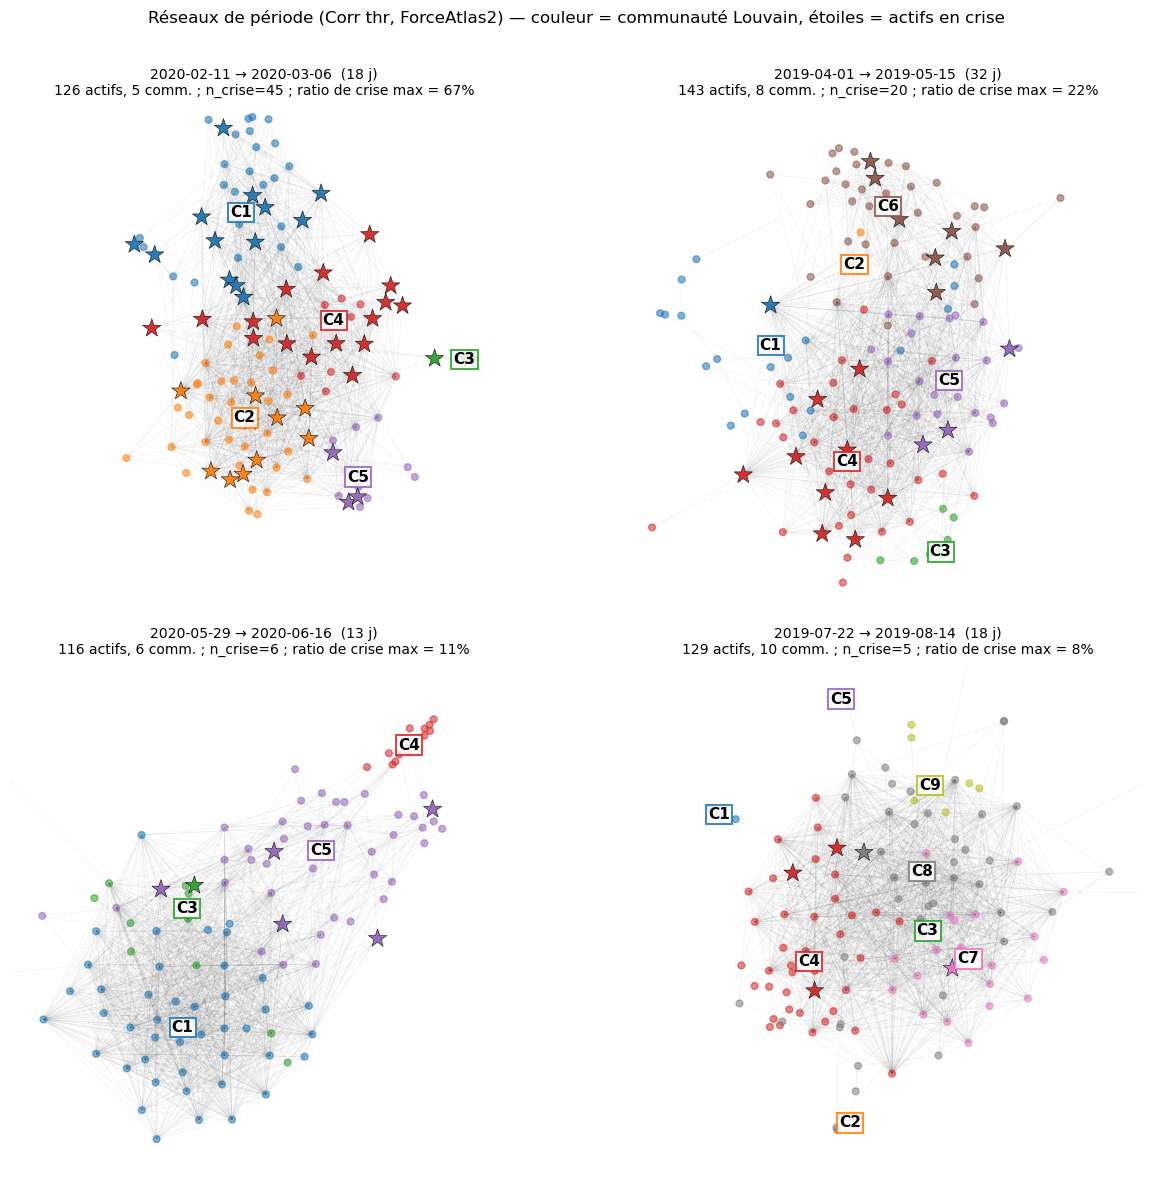

In [20]:
# Graphes des 4 grandes crises : couleur = communauté Louvain, actifs en crise = étoiles.
# Rendu ForceAtlas2 (gravité FAIBLE). Communautés = définition commune du §6 (_graph_comms :
# communautés de taille 1 (actions isolées) retirées, résolution par défaut — définie plus haut).
from fa2_modified import ForceAtlas2

GRAVITY_G = 0.05        # gravité ForceAtlas2 (faible -> communautés plus étalées, meilleur rendu)
_fa2 = ForceAtlas2(scalingRatio=30.0, gravity=GRAVITY_G, edgeWeightInfluence=0.3,
                   strongGravityMode=False, outboundAttractionDistribution=True, verbose=False)
sel4 = sorted([w for w in big if len(_crisis_opt(*w)) >= 2], key=lambda w: -len(_crisis_opt(*w)))[:4]
cmap = plt.get_cmap('tab10')
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
for ax, (pa, pb) in zip(axes.ravel(), sel4):
    crisis = _crisis_opt(pa, pb)
    G, comm, n2c = _graph_comms(pa, pb)
    crisis_in = crisis & set(G.nodes())
    rmax = max((len(c & crisis) / len(c) for c in comm), default=0.0)
    ndays = pb - pa + 1                                             # durée de la période (jours de bourse)
    pos = _fa2.forceatlas2_networkx_layout(G, pos=None, iterations=2000)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.05, width=0.5)
    nc = [n for n in G.nodes() if n not in crisis]
    cc = [n for n in G.nodes() if n in crisis]
    nx.draw_networkx_nodes(G, pos, nodelist=nc, node_color=[cmap(n2c[n] % 10) for n in nc],
                           node_size=24, ax=ax, alpha=0.55)
    nx.draw_networkx_nodes(G, pos, nodelist=cc, node_color=[cmap(n2c[n] % 10) for n in cc],
                           node_shape='*', node_size=190, edgecolors='k', linewidths=0.4, ax=ax, alpha=0.95)
    # cadrage carré centré sur le cœur dense (les nœuds éloignés sont clippés hors champ)
    xs = np.array([pos[n][0] for n in G.nodes()]); ys = np.array([pos[n][1] for n in G.nodes()])
    cx, cy = np.median(xs), np.median(ys)
    h = max(np.percentile(np.abs(xs - cx), 95), np.percentile(np.abs(ys - cy), 95)) * 1.15 + 1e-9
    ax.set_xlim(cx - h, cx + h); ax.set_ylim(cy - h, cy + h); ax.set_aspect('equal')
    for ci, c in enumerate(comm):                                  # label de chaque communauté (centroïde robuste)
        cn = [n for n in c if n in pos]
        if not cn:
            continue
        mx = np.median([pos[n][0] for n in cn]); my = np.median([pos[n][1] for n in cn])
        if not (cx - h <= mx <= cx + h and cy - h <= my <= cy + h):
            continue                                               # centroïde hors cadre -> pas de label flottant
        ax.text(mx, my, f'C{ci+1}', fontsize=11, fontweight='bold', ha='center', va='center',
                clip_on=True, bbox=dict(fc='white', ec=cmap(ci % 10), alpha=0.85, pad=1.5, lw=1.5))
    ax.set_title(f'{str(all_days[pa])[:10]} → {str(all_days[pb])[:10]}  ({ndays} j)\n'
                 f'{G.number_of_nodes()} actifs, {len(comm)} comm. ; '
                 f'n_crise={len(crisis_in)} ; ratio de crise max = {100*rmax:.0f}%', fontsize=10)
    ax.axis('off')
plt.suptitle('Réseaux de période (Corr thr, ForceAtlas2) — couleur = communauté Louvain, étoiles = actifs en crise',
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

In [21]:
# Pour chaque communauté Louvain des 4 mêmes graphes (mêmes réglages) : secteur majoritaire + durée.
from collections import Counter
_sec = pd.read_excel(config.DATA_DIR / "stock_category.xlsx").set_index("Stocks")["Sectors"]
for (pa, pb) in sel4:
    crisis = _crisis_opt(pa, pb)
    G, comm, _ = _graph_comms(pa, pb)
    print(f'{str(all_days[pa])[:10]} → {str(all_days[pb])[:10]}  ({pb-pa+1} j, {len(comm)} communautés)')
    for ci, c in enumerate(comm):
        secs = Counter(_sec.get(ctx.data.columns[n], '?') for n in c)   # n = indice -> ticker -> secteur
        top, k = secs.most_common(1)[0]
        ncr = len(c & crisis)
        print(f'  C{ci+1:<2} (n={len(c):>3}) : {top:<24} {100*k/len(c):>3.0f}%   [en crise : {ncr}]')
    print()

2020-02-11 → 2020-03-06  (18 j, 5 communautés)
  C1  (n= 38) : Healthcare                39%   [en crise : 13]
  C2  (n= 45) : Financials                27%   [en crise : 11]
  C3  (n=  5) : Healthcare               100%   [en crise : 2]
  C4  (n= 24) : Information Technology    50%   [en crise : 16]
  C5  (n= 14) : Information Technology    93%   [en crise : 3]

2019-04-01 → 2019-05-15  (32 j, 8 communautés)
  C1  (n= 20) : Consumer Staples          25%   [en crise : 1]
  C2  (n=  3) : Consumer Staples         100%   [en crise : 0]
  C3  (n=  8) : Energy                    88%   [en crise : 0]
  C4  (n= 40) : Financials                42%   [en crise : 9]
  C5  (n= 26) : Information Technology    54%   [en crise : 3]
  C6  (n= 41) : Healthcare                56%   [en crise : 7]
  C7  (n=  2) : Information Technology    50%   [en crise : 0]
  C8  (n=  3) : Utilities                100%   [en crise : 0]

2020-05-29 → 2020-06-16  (13 j, 6 communautés)
  C1  (n= 43) : Financials         

**Lecture (actifs en crise = expliqués par le SIS, R²>0.6, à leur (B, R) optimal ; communautés Louvain à résolution par défaut, communautés de taille 1 — actions isolées — retirées ; on ne touche pas au reste du réseau).**

- **Le filtre SIS est très sélectif** : COVID passe de 139 détectés à **47** retenus, avril 2019 de 73 à **20**, et **toutes les autres montées tombent à 0–6** (4 périodes à 0). Hors des 2 grandes crises, quasiment aucun actif n'est proprement modélisé.
- **Concentration partielle, pas de communauté de crise unique.** Une fois les actions isolées écartées, il reste 5–10 communautés par grande crise. La plus contaminée est **modérément enrichie** : COVID **67 %** de crise sur une sous-communauté de **24** actifs (vs 36 % attendu, +31 pts, ≈ 3,5 σ) ; avril 2019 **22 %** sur 40 actifs (vs 14 %, +8 pts). **Mais** les **plus grosses** communautés restent au niveau du hasard, voire en dessous (COVID : la communauté de 45 nœuds n'a que 24 % de crise), et **aucune** communauté n'atteint 2× le taux global (colonne « contaminées >2x » = 0 sur les grandes crises).
- Les actifs en crise se **répartissent** donc sur plusieurs communautés : il n'y a pas une communauté qui les rassemblerait.

**Conclusion.** Les actifs en crise **ne forment pas une communauté commune** : ils sont dispersés, la plus grosse communauté étant au niveau du hasard. Il subsiste une **sous-communauté modérément enrichie** (COVID 24 actifs à 67 %), significative mais sous le seuil de 2× — et **dépendante de l'échelle** : à résolution plus grossière elle fusionne dans une grande communauté au taux de base. Une crise collective reste **largement systémique et inter-communautés**. Réserve : ce filtrage **vide presque les périodes** (2 réellement interprétables), la puissance statistique est faible.

## 7. Contamination par période — score endo/exo reproductible

Un score identique sur les 17 montées (littérature endo/exo des marchés) :

- **Exogène** : réaction à une info *extérieure* ; les mouvements ne s'auto-entretiennent pas.
- **Endogène** : le marché s'excite *lui-même* (réflexivité, cascade).
- **Score n** (ratio de branchement) : **n = 1 − 1/√(Var/Moyenne)** des sauts journaliers d'actifs. **n → 0 exogène · n → 1 endogène.** (Filimonov-Sornette 2012 ; Hardiman-Bouchaud 2014.)

On le compare à la contamination réelle au sens du **SIS** (§5).


,période,événement,n (endo/exo),détectés,% détectés,SIS@opt,% SIS
0,2019-04-01 → 2019-05-15,Guerre commerciale US-Chine,0.80,73,50.0,20,13.7
1,2019-07-22 → 2019-08-14,Réescalade tarifs / inversion courbe,0.85,38,26.0,5,3.4
2,2019-11-19 → 2020-02-04,Pré-COVID / accord phase 1,0.79,19,13.0,0,0.0
3,2020-02-11 → 2020-03-06,Krach COVID-19,0.94,139,95.2,47,32.2
4,2020-05-29 → 2020-06-16,Peur 2e vague COVID,0.90,94,64.4,6,4.1
5,2020-08-24 → 2020-09-14,Correction tech (Nasdaq),0.89,5,3.4,0,0.0
6,2020-10-19 → 2020-11-04,2e vague + élection US + vaccin,0.84,25,17.1,0,0.0
7,2020-12-10 → 2021-03-04,Reflation / GameStop,0.89,6,4.1,0,0.0
8,2021-03-29 → 2021-05-13,Craintes inflation (printemps),0.76,8,5.5,0,0.0
9,2021-08-05 → 2021-09-29,Evergrande + taper Fed,0.79,37,25.3,1,0.7


Réflexivité intra-barre (30 min) ≈ 0.85 sur tout l'échantillon -> criticité apparente : le marché est quasi-critique en permanence (Hardiman-Bouchaud).
Au pas JOURNALIER, le score se différencie : n de 0.73 (le plus exogène) à 0.94 (le plus endogène). AUCUNE période proche de 0 : composante endogène partout.
Plus endogène : Krach COVID-19 (n=0.94) — c'est aussi la seule à montrer une vraie propagation SIS (§5-7).
Spearman(n, % contaminés SIS) = 0.25 (positif mais modéré, n=17) ; l'accord net est au SOMMET : COVID = le plus endogène ET le plus contaminé.


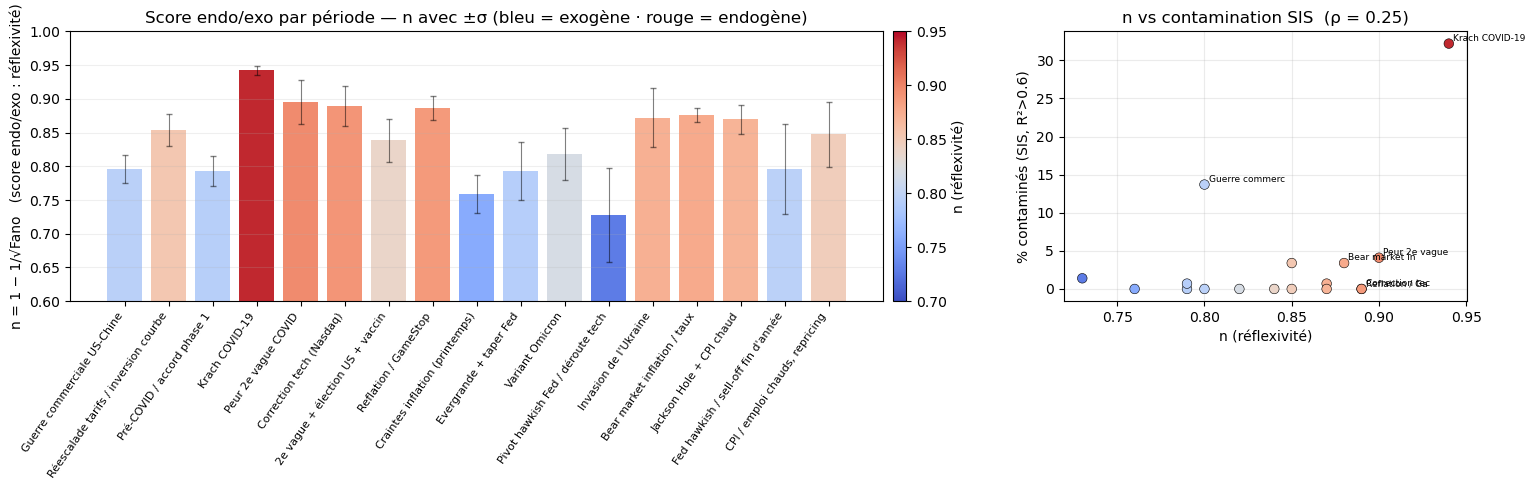

In [22]:
# ── §7 — Score endo/exo REPRODUCTIBLE : ratio de branchement (réflexivité) ──────
# Critère tiré de la littérature (Filimonov & Sornette 2012 ; Hardiman & Bouchaud
# 2014) et calculé IDENTIQUEMENT sur les 17 montées : n = 1 - 1/sqrt(Var/Moyenne)
# des comptages journaliers de « sauts » d'actifs (|r|>3x médiane). n->1 : cascade
# ENDOGENE (auto-excitation) ; n->0 : chocs EXOGENES (poissoniens). cf. code/endo_exo.py.
import endo_exo, importlib; importlib.reload(endo_exo)  # recharge le module sans redémarrer le kernel
from scipy.stats import spearmanr
from matplotlib.cm import ScalarMappable

# Nommage des événements (les SOURCES fiables sont dans le tableau §7.1).
PERIOD_TAGS = {
    '2019-04-01': 'Guerre commerciale US-Chine',
    '2019-07-22': 'Réescalade tarifs / inversion courbe',
    '2019-11-19': 'Pré-COVID / accord phase 1',
    '2020-02-11': 'Krach COVID-19',
    '2020-05-29': 'Peur 2e vague COVID',
    '2020-08-24': 'Correction tech (Nasdaq)',
    '2020-10-19': '2e vague + élection US + vaccin',
    '2020-12-10': 'Reflation / GameStop',
    '2021-03-29': 'Craintes inflation (printemps)',
    '2021-08-05': 'Evergrande + taper Fed',
    '2021-11-09': 'Variant Omicron',
    '2022-01-03': 'Pivot hawkish Fed / déroute tech',
    '2022-02-08': "Invasion de l'Ukraine",
    '2022-04-08': 'Bear market inflation / taux',
    '2022-08-01': 'Jackson Hole + CPI chaud',
    '2022-12-02': "Fed hawkish / sell-off fin d'année",
    '2023-01-20': 'CPI / emploi chauds, repricing',
}
def _tag(pa):
    return PERIOD_TAGS.get(str(all_days[pa])[:10], '?')

# Score endo/exo n (réflexivité) calculé identiquement sur les 17 montées + σ bootstrap.
reflex = endo_exo.reflexivity_by_period(ctx, peak_rises)

# Réflexivité intra-barre (30 min) sur tout l'échantillon : ~constante -> "criticité
# apparente" (Hardiman & Bouchaud 2014) ; c'est au pas JOURNALIER que n différencie.
n_intra = endo_exo.branching_ratio(endo_exo.market_jump_activity(ctx.data))

# Tableau : score endo/exo n vs contamination réellement expliquée par le SIS (§5).
rows = []
for i, (pa, pb) in enumerate(peak_rises):
    detect = len(peak_pd[(pa, pb)][0])
    sis_opt = set().union(*(opt_sets_pm[(pa, pb)][m] for m in config.SIS_MODELS))
    r = reflex.iloc[i]
    rows.append({'période': f'{str(all_days[pa])[:10]} → {str(all_days[pb])[:10]}',
                 'événement': _tag(pa),
                 'n (endo/exo)': round(float(r['n']), 2),
                 'détectés': detect, '% détectés': round(100 * detect / N, 1),
                 'SIS@opt': len(sis_opt), '% SIS': round(100 * len(sis_opt) / N, 1)})
contam = pd.DataFrame(rows)
display(contam)

nmin, nmax = contam['n (endo/exo)'].min(), contam['n (endo/exo)'].max()
top = contam.loc[contam['n (endo/exo)'].idxmax()]
rho = spearmanr(contam['n (endo/exo)'], contam['% SIS']).correlation
print(f"Réflexivité intra-barre (30 min) ≈ {n_intra:.2f} sur tout l'échantillon "
      f"-> criticité apparente : le marché est quasi-critique en permanence (Hardiman-Bouchaud).")
print(f"Au pas JOURNALIER, le score se différencie : n de {nmin:.2f} (le plus exogène) à "
      f"{nmax:.2f} (le plus endogène). AUCUNE période proche de 0 : composante endogène partout.")
print(f"Plus endogène : {top['événement']} (n={top['n (endo/exo)']:.2f}) — c'est aussi "
      f"la seule à montrer une vraie propagation SIS (§5-7).")
print(f"Spearman(n, % contaminés SIS) = {rho:.2f} (positif mais modéré, n=17) ; "
      f"l'accord net est au SOMMET : COVID = le plus endogène ET le plus contaminé.")

# ── Figure : score n par période (couleur = n, échelle absolue) + n vs SIS ─────
cmap = plt.get_cmap('coolwarm')                # bleu = exogène (n bas), rouge = endogène (n haut)
norm = plt.Normalize(0.70, 0.95)
cols = cmap(norm(reflex['n'].values))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15.5, 5.0),
                               gridspec_kw={'width_ratios': [2.4, 1]})
x = np.arange(len(peak_rises))
yerr = reflex['n_sd'].values
ax1.bar(x, reflex['n'], color=cols, yerr=yerr, capsize=2,
        error_kw=dict(lw=0.8, alpha=0.5))
ax1.set_xticks(x)
ax1.set_xticklabels([_tag(pa) for (pa, pb) in peak_rises], rotation=55, ha='right', fontsize=8)
ax1.set_ylabel('n = 1 − 1/√Fano   (score endo/exo : réflexivité)')
ax1.set_ylim(0.6, 1.0)
ax1.set_title('Score endo/exo par période — n avec ±σ (bleu = exogène · rouge = endogène)')
sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
fig.colorbar(sm, ax=ax1, pad=0.01).set_label('n (réflexivité)')
ax1.grid(alpha=0.2, axis='y')

nq75 = reflex['n'].quantile(0.75)
ax2.scatter(contam['n (endo/exo)'], contam['% SIS'], c=cols, s=48, edgecolor='k', lw=0.4, zorder=3)
for _, rr in contam.iterrows():
    if rr['% SIS'] > 8 or rr['n (endo/exo)'] >= nq75:
        ax2.annotate(rr['événement'][:14], (rr['n (endo/exo)'], rr['% SIS']), fontsize=6.5,
                     xytext=(3, 2), textcoords='offset points')
ax2.set_xlabel('n (réflexivité)')
ax2.set_ylabel('% contaminés (SIS, R²>0.6)')
ax2.set_title(f'n vs contamination SIS  (ρ = {rho:.2f})')
ax2.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [23]:
# ── Tableau récap : période · tag · score endo/exo · % stocks R²>0.6 ───────────
# Projection propre de `contam` : tag = événement, score = n (réflexivité), et
# % stocks R²>0.6 = part des actifs (sur N) dont le fit SIS dépasse R²>0.6 (union des
# 4 méthodes, chacune à son (B,R) optimal ; quasi identique à B=R=1, écart < 1.5 pt).
tab_endo_exo = (contam[['période', 'événement', 'n (endo/exo)', '% SIS']]
                .rename(columns={'événement': 'tag',
                                 'n (endo/exo)': 'score endo/exo (n)',
                                 '% SIS': '% stocks R²>0.6'}))
display(tab_endo_exo)

,période,tag,score endo/exo (n),% stocks R²>0.6
0,2019-04-01 → 2019-05-15,Guerre commerciale US-Chine,0.80,13.7
1,2019-07-22 → 2019-08-14,Réescalade tarifs / inversion courbe,0.85,3.4
2,2019-11-19 → 2020-02-04,Pré-COVID / accord phase 1,0.79,0.0
3,2020-02-11 → 2020-03-06,Krach COVID-19,0.94,32.2
4,2020-05-29 → 2020-06-16,Peur 2e vague COVID,0.90,4.1
5,2020-08-24 → 2020-09-14,Correction tech (Nasdaq),0.89,0.0
6,2020-10-19 → 2020-11-04,2e vague + élection US + vaccin,0.84,0.0
7,2020-12-10 → 2021-03-04,Reflation / GameStop,0.89,0.0
8,2021-03-29 → 2021-05-13,Craintes inflation (printemps),0.76,0.0
9,2021-08-05 → 2021-09-29,Evergrande + taper Fed,0.79,0.7


### 7.1 Score endo/exo et sources

**Calcul du score** (identique pour chaque période) :
1. **Saut** d'un actif = barre 30 min où |rᵢ| > 3× sa propre médiane de |rᵢ| (règle invariante d'échelle).
2. On **compte les sauts** de tous les actifs **par jour** → une série de comptages journaliers.
3. **Fano** F = Var/Moyenne de ces comptages (F = 1 : hasard/poissonien ; F > 1 : les sauts s'agglutinent).
4. **n = 1 − 1/√F** : pour un processus auto-excitant (Hawkes), F → 1/(1−n)², donc n = part endogène (∈ [0, 1[).
- **n = dynamique, pas la cause** : un choc externe (COVID, Fed) peut être endogène si le marché l'amplifie.
- **Résultat** : n = 0.73–0.94 partout → aucune crise « purement exogène ». **COVID le plus endogène (0.94)** = seule vraie propagation SIS. À 30 min, n ≈ 0.84 partout (criticité apparente).

| Période | Événement déclencheur | *n* [IC95] | Source (fiable) |
|---|---|---|---|
| 2019-04 → 05 | Escalade tarifaire US-Chine (menace de hausse des droits de douane, mai 2019) | 0.80 [0.74, 0.82] | [NY Fed — trade war & stock returns](https://libertystreeteconomics.newyorkfed.org/2024/12/using-stock-returns-to-assess-the-aggregate-effect-of-the-u-s-china-trade-war/) |
| 2019-07 → 08 | Yuan > 7, « manipulateur », inversion 10a-2a, peur de récession (août 2019) | 0.85 [0.79, 0.88] | [Washington Post](https://www.washingtonpost.com/business/2019/08/14/stocks-tank-another-recession-warning-surfaces/) |
| 2019-11 → 2020-02 | Marché calme, accord commercial de phase 1 (janv. 2020) ; montée de faible amplitude | 0.79 [0.74, 0.83] | [NY Fed — trade war & stock returns](https://libertystreeteconomics.newyorkfed.org/2024/12/using-stock-returns-to-assess-the-aggregate-effect-of-the-u-s-china-trade-war/) |
| 2020-02 → 03 | **Krach COVID-19** : pandémie, confinements mondiaux (pic d'activité daté févr. 2020) | **0.94 [0.93, 0.95]** | [NBER — datation du pic févr. 2020](https://www.nber.org/news/business-cycle-dating-committee-announcement-june-8-2020) |
| 2020-05 → 06 | 2e vague (TX/FL) + Fed prudente sur la reprise (FOMC 10 juin 2020, −7 % Dow) | 0.90 [0.81, 0.92] | [Fed — communiqué FOMC 10 juin 2020](https://www.federalreserve.gov/newsevents/pressreleases/monetary20200610a.htm) |
| 2020-08 → 09 | Correction tech : valorisations extrêmes / dégonflement (sept. 2020) | 0.89 [0.81, 0.91] | [Fed — Financial Stability Report nov. 2020 (Asset Valuations)](https://www.federalreserve.gov/publications/2020-november-financial-stability-report-asset-valuation.htm) |
| 2020-10 → 11 | 2e vague + élection US + annonce vaccin Pfizer (9 nov. 2020, efficacité > 90 %) | 0.84 [0.75, 0.87] | [Pfizer — communiqué 9 nov. 2020](https://www.pfizer.com/news/press-release/press-release-detail/pfizer-and-biontech-announce-vaccine-candidate-against) |
| 2020-12 → 2021-03 | Reflation / taux longs en hausse + épisode GameStop (janv.-févr. 2021) | 0.89 [0.84, 0.91] | [SEC — Staff Report on Early-2021 Market Structure](https://www.sec.gov/files/staff-report-equity-options-market-struction-conditions-early-2021.pdf) |
| 2021-03 → 05 | Craintes d'inflation, bond des rendements du Trésor, rotation value/growth | 0.76 [0.69, 0.79] | [Fed/FRED — rendement du Trésor 10 ans (DGS10)](https://fred.stlouisfed.org/series/DGS10) |
| 2021-08 → 09 | Quasi-défaut d'Evergrande (Chine) + attentes de tapering Fed (sept. 2021) | 0.79 [0.68, 0.84] | [NPR — Evergrande & Wall Street](https://www.npr.org/2021/09/20/1038944385/china-evergrande-wall-street-stocks-selloff) |
| 2021-11 | Variant Omicron, « Black Friday » 26 nov. 2021 (pire séance de l'année) | 0.82 [0.71, 0.85] | [Washington Post — Black Friday Omicron](https://www.washingtonpost.com/business/2021/11/26/stock-market-black-friday/) |
| 2022-01 | Virage restrictif de la Fed, anticipation des hausses, déroute tech (janv. 2022) | 0.73 [0.53, 0.79] | [Fed — communiqué FOMC 26 janv. 2022](https://www.federalreserve.gov/newsevents/pressreleases/monetary20220126a.htm) |
| 2022-02 → 03 | **Invasion de l'Ukraine** (24 févr. 2022), flambée des matières premières | 0.87 [0.73, 0.90] | [St. Louis Fed — Ukraine & stock prices](https://www.stlouisfed.org/on-the-economy/2022/jun/russia-invasion-ukraine-impact-stock-prices) |
| 2022-04 → 06 | Inflation record, cycle de hausses Fed, pire S1 depuis 1970 | 0.88 [0.85, 0.89] | [Fed — Financial Stability Report mai 2022 (Asset Valuations)](https://www.federalreserve.gov/publications/2022-may-financial-stability-report-asset-valuation.htm) |
| 2022-08 → 09 | Jackson Hole (Powell, 26 août) + CPI chaud (13 sept. 2022, −4,3 % S&P) | 0.87 [0.82, 0.90] | [Fed — discours Powell Jackson Hole](https://www.federalreserve.gov/newsevents/speech/powell20220826a.htm) · [BLS — CPI 13 sept. 2022](https://www.bls.gov/news.release/archives/cpi_09132022.pdf) |
| 2022-12 | Fed restrictive (FOMC 14 déc.), dégagements de fin d'année (déc. 2022) | 0.80 [0.62, 0.85] | [Fed — communiqué FOMC 14 déc. 2022](https://www.federalreserve.gov/newsevents/pressreleases/monetary20221214a.htm) |
| 2023-01 → 02 | CPI et emploi solides, repricing des taux (janv.-févr. 2023, avant SVB) | 0.85 [0.67, 0.87] | [BLS — Consumer Price Index](https://www.bls.gov/cpi/) |

**Lecture.** Sommet coïncide (COVID = plus endogène ET plus contaminé), mais ρ(n, % SIS) ≈ 0.25 → propagation **partielle**, surtout du co-mouvement de masse.


### 7.2 Littérature

- **Réflexivité (Sornette).** Marchés quasi-critiques (n ≈ 0.9) — retrouvé ici (n ≈ 0.84 à 30 min) : l'endogénéité est la règle, c'est son *degré* (journalier) qui distingue les crises. *Filimonov & Sornette, PRE 85 (2012) ; Hardiman & Bouchaud, PRE 90 (2014).*
- **Usman et al. (2024).** Vocabulaire ~inversé (leur *endogène* = choc de marché propagé). Traduit, on converge : COVID = événement de marché global, très réflexif. *QREF 94 (2024) 281–293, [doi](https://doi.org/10.1016/j.qref.2024.02.004).*


## 8. Conclusion — SIS : détecteur de crise, pas modèle de contagion

**Descriptif oui, contagion non.** Le bon fit SIS sur les grandes crises vient du **co-mouvement** (tout monte ensemble → une logistique colle), pas d'une propagation actif-par-actif.

**Pour « ça marche » :**
- **Sélectif** (§4) : R² > 0.6 sur ~6–9 % hors crise vs ~18–20 % en crise collective (2–3×).
- **Concentré** (§5) : actifs retenus massés sur COVID (44–46) et guerre commerciale 2019 (14–16) ; ~75 % d'accord entre les 4 méthodes.

**Contre « c'est de la contagion » :**
- **Pas de communauté** (§6) : pendant COVID, 34 % dans la communauté dominante vs 32 % au hasard (excès nul).
- **Réflexivité ≠ diffusion sur le graphe** (§7) : n = 0.73–0.94 partout (aucune crise « purement exogène »), mais contamination SIS > 10 % pour 2 périodes seulement ; n suit le SIS au sommet (COVID).

**Verdict.** Bon **détecteur** de crise systémique, **pas** un modèle de contagion. Seule propagation crédible : **COVID** (et, plus faiblement, guerre commerciale 2019).


## 9. Test de caducité — le SIS est-il un modèle de contagion *falsifiable* ?

Question rigoureuse : à quelle condition ce modèle serait-il **réfuté** ? Tant qu'on ne sait pas y répondre, « bon R² » ne prouve rien.

**Pourquoi le R² ne tranche pas.** La trajectoire SIS x_i(t) est recadrée sur le temps de convergence T_conv puis comparée à E_i(t) par **régression linéaire** (invariante par transformation affine) : ce qui reste, c'est une **rampe monotone saturante**. Or en crise collective *tout* E_i est une rampe saturante — **quelle que soit** la matrice A. Contagion (propagation actif→actif le long de A) et co-mouvement (facteur commun de marché) prédisent donc **le même** bon fit : ils sont **observationnellement équivalents** au niveau du R². Le modèle n'est testable qu'en attaquant son **mécanisme** — la propagation *sur A* — pas son ajustement.

**Règle de décision, fixée _avant_ de regarder les résultats.**

- **Test A — falsifiabilité du fit.** Refaire les fits des actifs bien ajustés en remplaçant A par des matrices qui **détruisent la topologie** mais gardent le régime épidémique (même rayon spectral λ_max) : (i) **ré-étiquetage** des nœuds P·A·Pᵀ (spectre identique, voisinages brouillés), (ii) **facteur commun** de rang 1 (chaque actif couplé au seul « marché »), (iii) couplage **uniforme**. *Si* le taux de bons fits est indiscernable entre A réel et ces nulls, alors le R² **ne peut pas falsifier** le modèle → on ne peut rien conclure du fit seul.
- **Test B — le mécanisme (décisif).** Le terme d'infection R·(1−x_i)·(A·x)_i dit qu'un actif s'« allume » d'autant plus vite que ses **voisins de réseau** sont déjà infectés. On teste ça sur l'état binaire journalier s_i(t) = « actif en crise » (`crisis_map`), par une **régression logistique emboîtée** de la transition s_i : 0→1 :
  - **M0** (co-mouvement) : logit P = α + a·f(t), avec f(t) = fraction **globale** infectée le jour t ;
  - **M1** (contagion) : logit P = α + a·f(t) + b·g_i(t), avec g_i(t) = fraction **des voisins de i** (pondérée par A) infectés.
  La contagion prédit **b > 0 significatif _après_ contrôle de f**. La significativité est jugée par un **null de permutation d'identités** : on permute quels actifs occupent les voisinages de A (ça détruit l'alignement A↔infection en conservant f, les taux de base et toute la structure temporelle → robuste à l'auto-corrélation des séries).
- **Verdict.** *Caduc comme contagion* (pur co-mouvement) si b est indistinguable du null de permutation (p_perm ≥ 0,05) ; *survit comme canal de contagion* si b > 0 avec p_perm < 0,05 sur la topologie réelle **et** une AUC d'allumage au-dessus de la bande de permutation.

[cache] OK  fal_testA


,methode,n,pc_reel,pc_reetiquete,pc_facteur_commun,pc_uniforme,R2moy_reel,R2moy_reetiq,R2moy_fcommun,R2moy_uniforme
0,PMFG,73,91.78,91.78,91.78,94.52,0.70,0.70,0.70,0.72
1,VAR(1),71,98.59,92.96,95.77,97.18,0.70,0.70,0.71,0.72
2,VAR(13),79,97.47,94.94,97.47,98.73,0.70,0.70,0.70,0.71
3,Corr thr,75,85.33,78.67,86.67,92.00,0.69,0.68,0.69,0.70


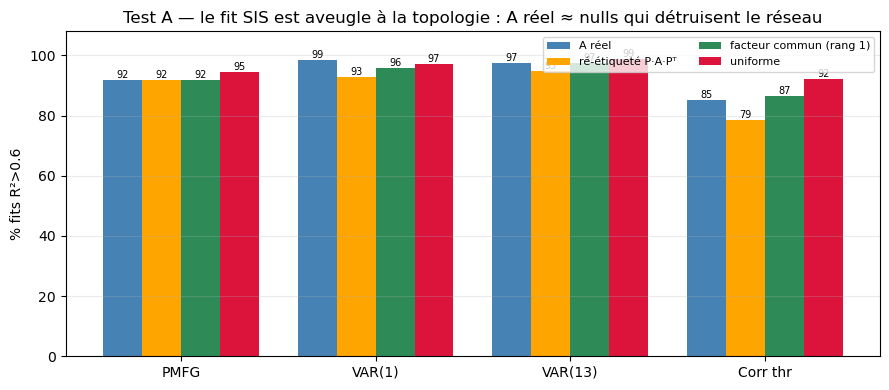

In [24]:
# -- §9 · TEST A -- le fit SIS est-il AVEUGLE à la topologie ? ------------------
# Pour les actifs bien ajustés (R²>seuil) en crise collective, on refait le fit en
# remplaçant A par des nulls qui détruisent la topologie À RÉGIME ÉPIDÉMIQUE CONSTANT
# (même rayon spectral λ_max) : ré-étiquetage P·A·Pᵀ, facteur commun (rang 1), uniforme.
from cache import disk_cache, sig_of

K_REL = 5                                    # nb de ré-étiquetages moyennés
def _spec_rad(M):
    return float(np.max(np.abs(np.linalg.eigvals(M))))

def _fal_test_A():
    _rng = np.random.default_rng(0)
    rows = []
    for m in config.SIS_MODELS:
        A = ctx.A_sis[m]; lamA = _spec_rad(A); s = A.sum(1)
        Acf = np.outer(s, s); np.fill_diagonal(Acf, 0.0); Acf *= lamA / _spec_rad(Acf)
        Au = np.ones((N, N)) - np.eye(N); Au *= lamA / _spec_rad(Au)
        perms = [_rng.permutation(N) for _ in range(K_REL)]
        def _r2(A_use, gi, d, E_i, ok):
            xt = sis.integrate_xscan(d, gi, A_use)
            return linregress(E_i[ok], xt[ok]).rvalue ** 2
        acc = {'real': [], 'relabel': [], 'cf': [], 'uni': []}
        for (pa, pb) in peak_rises:
            cache = peak_pd[(pa, pb)][0]; sl = peak_pd[(pa, pb)][1][m][1]
            for gi, d in cache.items():
                if sl.get(gi, {}).get('r2', 0.0) <= config.R2_SEUIL:
                    continue
                E_i = d['E_i']; ok = ~np.isnan(E_i)
                if ok.sum() < 3:
                    continue
                acc['real'].append(_r2(A, gi, d, E_i, ok))
                acc['cf'].append(_r2(Acf, gi, d, E_i, ok))
                acc['uni'].append(_r2(Au, gi, d, E_i, ok))
                acc['relabel'].append(np.mean([_r2(A[p][:, p], gi, d, E_i, ok) for p in perms]))
        a = {k: np.array(v) for k, v in acc.items()}; thr = config.R2_SEUIL
        rows.append(dict(methode=m, n=len(a['real']),
                         pc_reel=100 * np.mean(a['real'] > thr),
                         pc_reetiquete=100 * np.mean(a['relabel'] > thr),
                         pc_facteur_commun=100 * np.mean(a['cf'] > thr),
                         pc_uniforme=100 * np.mean(a['uni'] > thr),
                         R2moy_reel=np.mean(a['real']), R2moy_reetiq=np.mean(a['relabel']),
                         R2moy_fcommun=np.mean(a['cf']), R2moy_uniforme=np.mean(a['uni'])))
    return pd.DataFrame(rows)

sigA = sig_of(repr(peak_rises), config.R2_SEUIL, K_REL, config.T_LONG, 'fal_testA_v1')
tabA = disk_cache('fal_testA', sigA, _fal_test_A)
display(tabA.round(2))

_cols = [('pc_reel', 'A réel', 'steelblue'), ('pc_reetiquete', 'ré-étiqueté P·A·Pᵀ', 'orange'),
         ('pc_facteur_commun', 'facteur commun (rang 1)', 'seagreen'), ('pc_uniforme', 'uniforme', 'crimson')]
x = np.arange(len(tabA)); w = 0.2
fig, ax = plt.subplots(figsize=(9, 4))
for j, (col, lab, c) in enumerate(_cols):
    bb = ax.bar(x + (j - 1.5) * w, tabA[col], w, label=lab, color=c)
    ax.bar_label(bb, fmt='%.0f', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(tabA['methode']); ax.set_ylabel('% fits R²>0.6')
ax.set_title('Test A — le fit SIS est aveugle à la topologie : A réel ≈ nulls qui détruisent le réseau')
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.25, axis='y'); ax.set_ylim(0, 108)
plt.tight_layout(); plt.show()

**Lecture A.** Pour les quatre méthodes, la part de bons fits (R²>0,6) et le R² moyen sont **quasi identiques** entre A réel, A ré-étiqueté, facteur commun de rang 1 et couplage uniforme (R² moyen ≈ 0,70 partout ; 85–99 % de bons fits). **Le fit SIS est aveugle à la topologie** : un couplage « tout le monde au marché » ajuste aussi bien que le vrai réseau. Conséquence rigoureuse : **le R² ne peut pas servir de preuve de contagion** — il ne distingue pas propagation et co-mouvement. Il faut le test de mécanisme.

[cache] OK  fal_testB
17058 transitions · taux d'allumage 0.080 · 461 jours de crise


,methode,b_local,p_perm_b,AUC,AUC_null_moy,p_perm_AUC
0,PMFG,0.1270,0.0100,0.5900,0.5716,0.0050
1,VAR(1),-0.4257,0.8806,0.5988,0.6008,0.8706
2,VAR(13),-0.2799,0.8358,0.5990,0.6009,0.8706
3,Corr thr,0.1924,0.0050,0.6008,0.5785,0.0050


  PMFG      b=+0.127 p_perm=0.010 · AUC=0.590 (null 0.572) -> SURVIT (canal local réel)
  VAR(1)    b=-0.426 p_perm=0.881 · AUC=0.599 (null 0.601) -> CADUC (co-mouvement)
  VAR(13)   b=-0.280 p_perm=0.836 · AUC=0.599 (null 0.601) -> CADUC (co-mouvement)
  Corr thr  b=+0.192 p_perm=0.005 · AUC=0.601 (null 0.579) -> SURVIT (canal local réel)


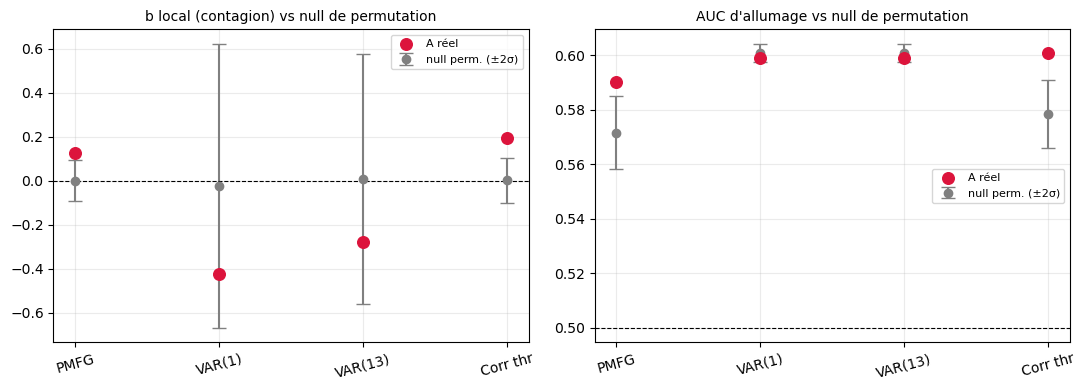

In [25]:
# -- §9 · TEST B -- transmission LOCALE vs GLOBALE (mécanisme, décisif) --------
# Régression logistique emboîtée de la transition s_i:0→1 (crisis_map) :
#   M0 : logit P = α + a·f       (f = fraction GLOBALE infectée)
#   M1 : logit P = α + a·f + b·g  (g = fraction des VOISINS de i infectés, pondérée par A)
# Significativité de b jugée par un NULL DE PERMUTATION D'IDENTITÉS (on permute quels
# actifs occupent les voisinages de A : détruit l'alignement A↔infection, garde f et le temps).
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from cache import disk_cache, sig_of

def _fal_test_B(K_PERM=200, seed=0):
    _rng = np.random.default_rng(seed)
    D = crisis_map.shape[1]
    cdays = np.zeros(D, bool)
    for (a, b) in peak_rises:
        cdays[a:b + 1] = True
    ii, tt, yy = [], [], []
    for t in np.where(cdays)[0]:
        if t + 1 >= D:
            continue
        for i in np.where(~crisis_map[:, t])[0]:
            ii.append(i); tt.append(t); yy.append(int(crisis_map[i, t + 1]))
    ii = np.array(ii); tt = np.array(tt); yy = np.array(yy, float)
    f = crisis_map.mean(0)[tt]
    _z = lambda v: (v - v.mean()) / (v.std() if v.std() > 0 else 1.0)
    rows = []
    for m in config.SIS_MODELS:
        A = ctx.A_sis[m]; s = A.sum(1); s[s == 0] = np.nan
        g = ((A @ crisis_map) / s[:, None])[ii, tt]
        ok = ~np.isnan(g)
        Y, fz, gz = yy[ok], _z(f[ok]), _z(g[ok])
        r0 = sm.Logit(Y, sm.add_constant(fz)).fit(disp=0)
        r1 = sm.Logit(Y, sm.add_constant(np.column_stack([fz, gz]))).fit(disp=0)
        b_real = float(r1.params[-1]); lrt = 2 * (r1.llf - r0.llf)
        auc = roc_auc_score(Y, g[ok])
        bperm, aperm = [], []
        for _ in range(K_PERM):
            p = _rng.permutation(N)
            gp = ((A @ crisis_map[p]) / s[:, None])[ii, tt][ok]
            try:
                rp = sm.Logit(Y, sm.add_constant(np.column_stack([fz, _z(gp)]))).fit(disp=0)
                bperm.append(float(rp.params[-1]))
            except Exception:
                bperm.append(np.nan)
            aperm.append(roc_auc_score(Y, gp))
        bperm = np.array(bperm); bperm = bperm[~np.isnan(bperm)]; aperm = np.array(aperm)
        rows.append(dict(methode=m, b_local=b_real, LRT=lrt,
                         b_null_moy=bperm.mean(), b_null_sd=bperm.std(),
                         z_perm_b=(b_real - bperm.mean()) / bperm.std(),
                         p_perm_b=(1 + np.sum(bperm >= b_real)) / (len(bperm) + 1),
                         AUC=auc, AUC_null_moy=aperm.mean(), AUC_null_sd=aperm.std(),
                         z_perm_AUC=(auc - aperm.mean()) / aperm.std(),
                         p_perm_AUC=(1 + np.sum(aperm >= auc)) / (K_PERM + 1)))
    return pd.DataFrame(rows), dict(n=len(yy), taux=float(yy.mean()), jours=int(cdays.sum()))

sigB = sig_of(repr(peak_rises), 'fal_testB_v1', 200)
tabB, infoB = disk_cache('fal_testB', sigB, _fal_test_B)
print(f"{infoB['n']} transitions · taux d'allumage {infoB['taux']:.3f} · {infoB['jours']} jours de crise")
display(tabB[['methode', 'b_local', 'p_perm_b', 'AUC', 'AUC_null_moy', 'p_perm_AUC']].round(4))
for _, r in tabB.iterrows():
    surv = (r.b_local > 0) and (r.p_perm_b < 0.05) and (r.p_perm_AUC < 0.05)
    print(f"  {r.methode:9s} b={r.b_local:+.3f} p_perm={r.p_perm_b:.3f} · "
          f"AUC={r.AUC:.3f} (null {r.AUC_null_moy:.3f}) -> "
          f"{'SURVIT (canal local réel)' if surv else 'CADUC (co-mouvement)'}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4)); xm = np.arange(len(tabB))
for ax, real, mu, sd, base, ttl in [
        (axes[0], 'b_local', 'b_null_moy', 'b_null_sd', 0.0, 'b local (contagion) vs null de permutation'),
        (axes[1], 'AUC', 'AUC_null_moy', 'AUC_null_sd', 0.5, "AUC d'allumage vs null de permutation")]:
    ax.errorbar(xm, tabB[mu], yerr=2 * tabB[sd], fmt='o', color='gray', capsize=5, label='null perm. (±2σ)')
    ax.scatter(xm, tabB[real], color='crimson', s=70, zorder=3, label='A réel')
    ax.axhline(base, ls='--', color='k', lw=0.8)
    ax.set_xticks(xm); ax.set_xticklabels(tabB['methode'], rotation=15)
    ax.set_title(ttl, fontsize=10); ax.grid(alpha=0.25); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Lecture B & verdict.** Sur ~17 000 transitions (461 jours de crise, taux d'allumage 8 %) :

- **Réseaux de corrélation — canal de contagion faible mais réel.** PMFG et Corr thr donnent **b_local > 0** qui **survit** au null de permutation (p_perm ≈ 0,005–0,01) : à f global fixé, un actif dont les **voisins de corrélation** sont déjà en crise s'allume plus vite, et l'effet tient à la **vraie** topologie (pas au hasard de degré/activité). L'AUC d'allumage ≈ 0,59–0,60 dépasse la bande de permutation (≈ 0,57–0,58).
- **Réseaux causaux VAR — caducs.** VAR(1) et VAR(13) ont **b_local ≤ 0**, indistinguable (voire sous) le null (p_perm ≈ 0,84–0,89) : la topologie de Granger n'encode **aucune** transmission locale au-delà du facteur commun.
- **Ampleur.** L'effet réel est **petit** : AUC ≈ 0,59 (≈ +0,02 au-dessus du null), le facteur global f(t) explique l'essentiel de l'allumage.

**Conclusion — le modèle n'est pas caduc au sens strict, mais il est dominé par le co-mouvement.** Le test A montre que *le fit ne peut pas* falsifier le SIS ; le test B *le peut* — et tranche : il **existe** un canal de propagation locale, statistiquement robuste, sur le graphe de **corrélation** (nul sur le graphe **VAR**), mais **faible**. Autrement dit, la §8 tient et se durcit : SIS = **détecteur** de crise systémique (co-mouvement) **plus** un mince canal de contagion réel sur la topologie de corrélation. Pour *réfuter définitivement* la thèse « détecteur, pas contagion », il faudrait une AUC locale nettement > 0,6 robuste **hors échantillon** — ce que ces données ne montrent pas.

### 9.1 Test C — filtrer les actifs non en crise (réseau réduit)

Variante du test A côté *entrées* : au lieu de fixer la topologie, on **retire du système** les actifs qui ne sont pas en crise sur la période — A devient la sous-matrice A[S,S] (plus petite), l'état ne porte que sur les actifs en crise S, les autres ne peuvent plus ni s'infecter ni rétro-agir. Si le bon fit venait d'une **contagion entre actifs en crise**, réduire à S devrait le **conserver, voire l'améliorer** ; si le fit vit du **co-mouvement global**, la réduction ne changera rien.

**Lecture C** (712 fits par méthode, toutes les crises collectives). Réduire le réseau aux seuls actifs en crise **n'améliore pas** les fits de façon exploitable : R² moyen quasi inchangé (**gain ≤ +0,02** ; VAR(1) +0,020 et PMFG +0,015 les plus favorables, médiane ΔR² ≈ 0), part de R²>0,6 **stable** (~9–11 % → ~10–11 %). Le modèle est **aveugle à la taille du réseau** comme il l'est à sa topologie (test A) : la logistique recadrée colle au co-mouvement quel que soit l'univers d'actifs retenu. Le pooling porte pourtant sur toutes les périodes — y compris celles où **beaucoup** d'actifs sont retirés (pas seulement COVID, où l'ensemble en crise fait déjà ~139/146) : l'effet reste négligeable.

[cache] OK  fal_testC


,methode,n,pc_complet,pc_reduit,R2moy_complet,R2moy_reduit,dR2_moyen,dR2_median,frac_amelioration
0,PMFG,712,9.270,11.096,0.271,0.285,0.015,0.002,0.673
1,VAR(1),712,9.831,9.831,0.267,0.288,0.020,0.003,0.621
2,VAR(13),712,10.815,11.376,0.272,0.286,0.014,0.000,0.539
3,Corr thr,712,9.129,9.972,0.261,0.269,0.008,0.002,0.642


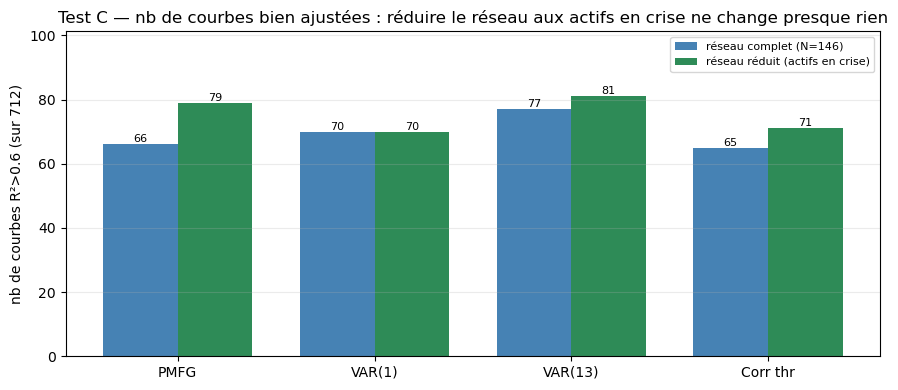

In [26]:
# -- §9 · TEST C -- restreindre le SIS aux SEULS actifs en crise (réseau plus petit) ----------
# "Filtrer" = enlever les actifs non en crise du réseau ET de l'univers : A -> A[S,S] (plus petite),
# x0 -> x0[S], on intègre le système RÉDUIT (Nc actifs). Les non-crise ne participent plus (aucune
# rétroaction). Question : est-ce que ça AMÉLIORE les fits ? (baseline = système complet à N actifs)
from cache import disk_cache, sig_of

def _fit_reduced():
    def _r2(cache_gi, gi_idx, A, E):
        ok = ~np.isnan(E)
        if ok.sum() < 3:
            return None
        return linregress(E[ok], sis.integrate_xscan(cache_gi, gi_idx, A)[ok]).rvalue ** 2
    big_c = [w for w in peak_rises if len(peak_pd[w][0]) >= 20]      # crises collectives
    rows = []
    for m in config.SIS_MODELS:
        A = ctx.A_sis[m]; base, red = [], []
        for (pa, pb) in big_c:
            cache = peak_pd[(pa, pb)][0]
            S = sorted(cache.keys()); idx = {gi: k for k, gi in enumerate(S)}
            A_S = A[np.ix_(S, S)]                                    # réseau réduit aux actifs en crise
            for gi, d in cache.items():
                E = d['E_i']; rb = _r2(d, gi, A, E)                  # baseline : système complet (N)
                if rb is None:
                    continue
                rf = _r2({'x0': d['x0'][S], 'n_days': d['n_days']}, idx[gi], A_S, E)  # réduit (Nc)
                base.append(rb); red.append(rf)
        base, red = np.array(base), np.array(red); thr = config.R2_SEUIL
        rows.append(dict(methode=m, n=len(base),
                         pc_complet=100 * np.mean(base > thr), pc_reduit=100 * np.mean(red > thr),
                         R2moy_complet=np.mean(base), R2moy_reduit=np.mean(red),
                         dR2_moyen=np.mean(red - base), dR2_median=np.median(red - base),
                         frac_amelioration=np.mean(red > base)))
    return pd.DataFrame(rows)

sigC = sig_of(repr(peak_rises), 'fal_testC_reduit_v1', config.R2_SEUIL)
tabC = disk_cache('fal_testC', sigC, _fit_reduced)
display(tabC.round(3))

# Nombre de courbes bien ajustées (R²>0.6) — reconstruit depuis les % du cache (pc = 100*k/n)
nb_complet = (tabC['pc_complet'] * tabC['n'] / 100).round().astype(int)
nb_reduit  = (tabC['pc_reduit']  * tabC['n'] / 100).round().astype(int)
x = np.arange(len(tabC)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - w / 2, nb_complet, w, color='steelblue', label='réseau complet (N=146)')
b2 = ax.bar(x + w / 2, nb_reduit, w, color='seagreen', label='réseau réduit (actifs en crise)')
ax.bar_label(b1, fmt='%d', fontsize=8); ax.bar_label(b2, fmt='%d', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(tabC['methode'])
ax.set_ylabel(f'nb de courbes R²>0.6 (sur {int(tabC["n"].iloc[0])})')
ax.set_ylim(0, max(nb_complet.max(), nb_reduit.max()) * 1.25)
ax.set_title("Test C — nb de courbes bien ajustées : réduire le réseau aux actifs en crise ne change presque rien")
ax.legend(fontsize=8); ax.grid(alpha=0.25, axis='y'); plt.tight_layout(); plt.show()